# Rome AirBnB Spatial and Price Analysis

The objective of this project is to analyze how property and spatial characteristics influence AirBnB pricing in Rome, Italy. Exploratory Data Analysis is conducted followed by regression modeling to predict the listing prices.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Rome_AirBnB/listings.csv.gz")

In [3]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2737,https://www.airbnb.com/rooms/2737,20250914152919,2025-09-15,city scrape,"Elif's room in cozy, clean flat.",10 min by bus you can get to Piazza Venezia or...,It used to be an industrial area until late 80...,https://a0.muscache.com/pictures/41225252/e955...,3047,https://www.airbnb.com/users/show/3047,Elif,2008-09-18,"Rome, Italy",I am a Turkish-Italian who was born in Istanbu...,a few days or more,0%,0%,f,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Testaccio,7.0,7.0,"['email', 'phone']",t,t,"Rome, Lazio, Italy",VIII Appia Antica,NaN,41.871360,12.482150,Private room,Private room,1,1.5,1.5 baths,1.0,1.0,"[""Hangers"", ""Heating"", ""Free parking on premis...",$57.00,31,1125,31.0,31.0,1125.0,1125.0,31.0,1125.0,NaN,t,30,60,90,365,2025-09-15,5,0,0,108,0,0,0.0,2014-12-26,2015-05-08,4.80,4.60,4.60,4.80,5.00,4.40,4.40,NaN,f,6,0,6,0,0.04
1,11834,https://www.airbnb.com/rooms/11834,20250914152919,2025-09-15,city scrape,"Charming Boschetto Studio, Rome",Fantastic apartment in the Monti district. The...,"""Monti"" with its narrow cobblestone alleys, cr...",https://a0.muscache.com/pictures/miso/Hosting-...,44552,https://www.airbnb.com/users/show/44552,Serena,2009-10-09,"Rome, Italy","Hello I'm Serena I was born and live in Rome, ...",within an hour,100%,95%,t,https://a0.muscache.com/im/users/44552/profile...,https://a0.muscache.com/im/users/44552/profile...,Monti,1.0,2.0,"['email', 'phone']",t,t,"Rome, Lazio, Italy",I Centro Storico,NaN,41.895447,12.491181,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Hangers"", ""Pack \u2019n play/Travel crib"", ""...",$110.00,2,28,2.0,2.0,28.0,28.0,2.0,28.0,NaN,t,3,24,52,295,2025-09-15,284,30,0,70,46,180,19800.0,2011-05-01,2025-07-05,4.86,4.87,4.93,4.97,4.96,4.99,4.81,IT058091C29VJSIZQZ,f,1,1,0,0,1.62
2,12398,https://www.airbnb.com/rooms/12398,20250914152919,2025-09-15,city scrape,Casa Donatello - Home far from Home,Casa Donatello is a newly renovated two-bedroo...,You are at 15 minutes walking distance from hi...,https://a0.muscache.com/pictures/miso/Hosting-...,11756,https://www.airbnb.com/users/show/11756,Gea,2009-03-30,"Rome, Italy","Hello to everybody,\r\nIt will be a pleasure t...",NaN,NaN,100%,t,https://z1.muscache.cn/im/users/11756/profile_...,https://z1.muscache.cn/im/users/11756/profile_...,Flaminio,1.0,2.0,"['email', 'phone']",t,t,"Rome, Lazio, Italy",II Parioli/Nomentano,NaN,41.925820,12.469280,Entire rental unit,Entire home/apt,6,1.0,1 bath,2.0,3.0,"[""Hangers"", ""Heating"", ""50 inch HDTV with stan...",$124.00,3,365,3.0,3.0,365.0,

Dataset is very thorough. There is lot of information about the rentals, but also about the host. This gives more credibility to the AirBnB brand itself and helps the potential future clients feel more prepared for the trip.

In [4]:
df.shape

(37652, 79)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37652 entries, 0 to 37651
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            37652 non-null  int64  
 1   listing_url                                   37652 non-null  object 
 2   scrape_id                                     37652 non-null  int64  
 3   last_scraped                                  37652 non-null  object 
 4   source                                        37652 non-null  object 
 5   name                                          37652 non-null  object 
 6   description                                   36703 non-null  object 
 7   neighborhood_overview                         17721 non-null  object 
 8   picture_url                                   37652 non-null  object 
 9   host_id                                       37652 non-null 

We see a big mix of numerical and categorical data types. To expand on that, data type 'object' also represents not just strings, but it can also be a list.

From this short summary we can see that there are null values in multiple columns, but to verify that we will put it into an actual report.

In [6]:
missing_data_report = df.isna().sum() / len(df) * 100
missing_data_report = missing_data_report.to_frame(name="percentage")
missing_data_report = missing_data_report[missing_data_report["percentage"] > 0].sort_values(by="percentage", ascending=False)

print('Missing Values Report:')
print('----------------------------------------')
print(missing_data_report)

Missing Values Report:
----------------------------------------
                              percentage
neighbourhood_group_cleansed  100.000000
calendar_updated              100.000000
host_neighbourhood             67.489111
host_about                     53.795283
neighbourhood                  52.934771
neighborhood_overview          52.934771
host_location                  26.189844
host_response_time             18.036226
host_response_rate             18.036226
review_scores_location         14.341868
review_scores_accuracy         14.339212
review_scores_value            14.339212
review_scores_checkin          14.339212
review_scores_communication    14.336556
review_scores_cleanliness      14.336556
last_review                    14.333900
reviews_per_month              14.333900
review_scores_rating           14.333900
first_review                   14.333900
estimated_revenue_l365d        10.857325
price                          10.857325
beds                           10.

Some columns are missing quite a bit of data. It is very important to understand a reason behind missingness in these columns before deciding how to handle these null values, which will be done through visualastion and trying to figure out what are connections between data in these columns in general.

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.765200e+04,3.765200e+04,3.765200e+04,37643.000000,37643.000000,0.0,37652.000000,37652.000000,37652.000000,33660.000000,36804.000000,33638.000000,37652.000000,37652.000000,37631.000000,37631.000000,37631.000000,37631.000000,37652.000000,37652.000000,0.0,37652.000000,37652.000000,37652.000000,37652.000000,37652.000000,37652.000000,37652.000000,37652.000000,37652.000000,37652.000000,3.356400e+04,32255.000000,32253.000000,32254.000000,32253.000000,32254.000000,32252.000000,32253.000000,37652.000000,37652.000000,37652.000000,37652.000000,32255.000000
mean,7.461415e+17,2.025091e+13,2.611336e+08,16.116542,24.237999,NaN,41.891249,12.480514,3.820780,1.307249,1.508640,2.215590,5.389939,346.162461,4.772581,6.622333,496.489836,551.138928,5.402111,522.474139,NaN,8.614363,24.548098,46.562228,216.343727,58.252682,14.134973,0.966004,59.057686,12.621853,80.001540,1.435278e+04,4.769581,4.804462,4.784221,4.844978,4.856055,4.753798,4.686264,9.467598,7.847657,1.527276,0.027701,1.744446
std,5.767852e+17,2.433626e+00,2.432036e+08,67.549298,130.416357,NaN,0.035233,0.049569,1.991687,0.668633,0.896519,1.469154,16.623835,401.670916,15.107453,31.114247,477.177024,487.800578,17.917441,479.653423,NaN,8.629943,17.247903,25.722540,116.493481,98.593674,18.788886,1.681061,30.864638,19.286675,90.332369,2.587653e+04,0.328004,0.312388,0.319584,0.287712,0.299506,0.317206,0.361069,27.352151,27.028811,3.706959,0.540813,1.626930
min,2.737000e+03,2.025091e+13,2.353000e+03,1.000000,1.000000,NaN,41.655820,12.242530,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.892659e+07,2.025091e+13,2.960476e+07,1.000000,1.000000,NaN,41.883231,12.459248,2.000000,1.000000,1.000000,1.000000,1.000000,29.000000,1.000000,2.000000,30.000000,30.000000,1.200000,30.000000,NaN,2.000000,12.000000,31.000000,119.000000,3.000000,0.000000,0.000000,41.000000,0.000000,0.000000,7.020000e+02,4.690000,4.750000,4.710000,4.810000,4.830000,4.650000,4.600000,1.000000,1.000000,0.000000,0.000000,0.440000
50%,9.477797e+17,2.025091e+13,1.757405e+08,3.000000,3.000000,NaN,41.896330,12.477691,4.000000,1.000000,1.000000,2.000000,2.000000,365.000000,2.000000,2.000000,365.000000,365.000000,2.000000,365.000000,NaN,6.000000,23.000000,49.000000,249.000000,18.000000,6.000000,0.000000,64.500000,2.000000,40.000000,6.102000e+03,4.860000,4.890000,4.880000,4.920000,4.950000,4.840000,4.760000,2.000000,1.000000,0.000000,0.000000,1.260000
75%,1.269260e+18,2.025091e+13,5.014931e+08,7.000000,9.000000,NaN,41.906594,12.505588,5.000000,1.500000,2.000000,3.000000,3.000000,365.000000,2.000000,3.000000,1125.000000,1125.000000,3.000000,1125.000000,NaN,12.000000,35.000000,64.000000,319.000000,68.000000,22.000000,1.000000,80.000000,19.000000,144.000000,1.989000e+04,4.970000,4.990000,4.990000,5.000000,5.000000,4.970000,4.890000,6.000000,3.000000,2.000000,0.000000,2.650000
max

In [9]:
df.describe(include='O')

,listing_url,last_scraped,source,name,description,neighborhood_overview,picture_url,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,property_type,room_type,bathrooms_text,amenities,price,has_availability,calendar_last_scraped,first_review,last_review,license,instant_bookable
count,37652,37652,37652,37652,36703,17721,37652,37652,37644,37643,27791,17397,30861,30861,33814,35456,37643,37643,12241,37643,37643,37643,17721,37652,37652,37652,37618,37652,33564,37058,37652,32255,32255,34589,37652
unique,37652,2,2,36682,33713,15191,37344,20523,3989,4958,573,7630,4,58,100,2,18723,18723,124,6,2,2,101,15,63,4,40,35634,1041,1,2,4246,1826,26958,2
top,https://www.airbnb.com/rooms/1509455305653425509,2025-09-15,city scrape,Appartamento,Relax in this peaceful and centrally-located p...,Located in the north of the city center Monti ...,https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/users/show/23532561,Andrea,2014-11-09,"Rome, Italy",iFlat is a Leading Property Management Company...,within an hour,100%,100%,f,https://a0.muscache.com/defaults/user_pic-50x5...,https://a0.muscache.com/defaults/user_pic-225x...,Prati,"['email', 'phone']",t,t,"Rome, Lazio, Italy",I Centro Storico,Entire rental unit,Entire home/apt,1 bath,"[""Air conditioning"", ""Wifi"", ""Washer"", ""Kitche...",$90.00,t,2025-09-15,2025-01-02,2025-09-12,"I applied for a CIN, but haven’t received it yet",t
freq,1,33064,33668,18,77,15,12,252,939,262,24828,254,26249,25365,22066,21734,2194,2194,1402,32488,35445,34564,17023,18563,18832,28294,20298,44,499,37058,33064,138,922,337,22855


After these brief summary statistics and before doing anything, let us just convert the 'price' column into numerical, since it will be used as target column in the regression modeling later on.

### Target Column Analysis

In [10]:
df['price'] = df['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

In [11]:
df['price'].describe()

,price
count,33564.000000
mean,197.328000
std,443.190521
min,8.000000
25%,93.000000
50%,133.000000
75%,195.250000
max,10515.000000


Now we can see actual statistics for it and that the average price of airbnb rental in Rome is around $200 per night, but there are some substantially lower and higher priced rentals as well. Now of course that depends on lot of factors which is exactly what will be explored in this project.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 500x400 with 0 Axes>

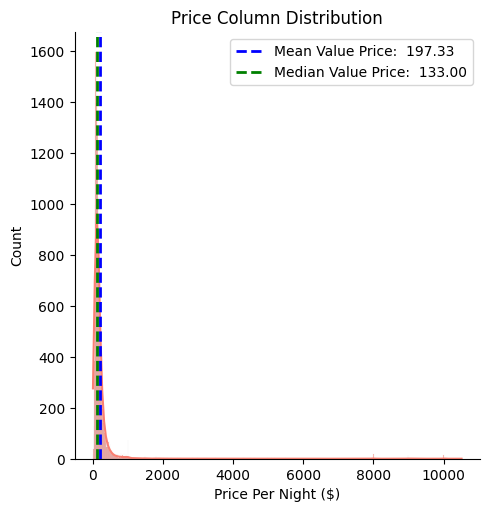

In [13]:
#Visualizing the distribution of 'price' (target) column
mean_price = df['price'].mean()
median_price = df['price'].median()

plt.figure(figsize=(5,4))
ax = sns.displot(data=df, x='price', kde=True, color='salmon')

plt.axvline(mean_price, color='blue', ls='--', linewidth=2, label=f"Mean Value Price: {mean_price: .2f}")
plt.axvline(median_price, color='green', ls='--', linewidth=2, label=f"Median Value Price: {median_price: .2f}")

plt.xlabel('Price Per Night ($)')
plt.title('Price Column Distribution')
plt.legend()
plt.show()

So the mean is higher than the median which is due to this very heavy tail to the right of the distribution. There are some spaces which are extremely higher priced than the vast majority of other spaces in the city.

<Figure size 500x400 with 0 Axes>

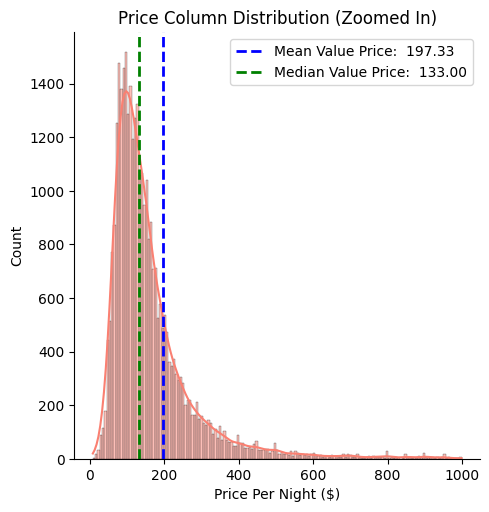

In [14]:
plt.figure(figsize=(5,4))
ax = sns.displot(x=df[df['price'] < 1000]['price'], kde=True, color='salmon')

plt.axvline(mean_price, color='blue', ls='--', linewidth=2, label=f"Mean Value Price: {mean_price: .2f}")
plt.axvline(median_price, color='green', ls='--', linewidth=2, label=f"Median Value Price: {median_price: .2f}")

plt.xlabel('Price Per Night ($)')
plt.title('Price Column Distribution (Zoomed In)')
plt.legend()
plt.show()

This is a zoomed in look into prices. From the previous plot we could see that the most of the room are priced below $1000 per night and even that seems from the plot to be very high.

Previous statistical call also told us that 75% of the prices are below $195 per night.

This was just visualizing the dataset if we removed some huge outliers, but in practice it needs to be studied and we need to see do those outliers depend on some specific amenities the airbnb rental has, because then it is a pattern and it is valuable information for making the predictions, or is it perhaps a mistake made when typing it information.

In [15]:
print('75th percentile: ', df['price'].quantile(0.75))
print('90th percentile: ', df['price'].quantile(0.9))
print('95th percentile: ', df['price'].quantile(0.95))
print('99th percentile: ', df['price'].quantile(0.99))
print('Max Value: ', df['price'].max())

75th percentile:  195.25
90th percentile:  304.0
95th percentile:  426.0
99th percentile:  1005.7400000000052
Max Value:  10515.0


In [16]:
quantile_99 = df['price'].quantile(0.99)
top_1_percent = df[df['price'] > quantile_99]

print('Top 1% of Listings on AirBnB in Rome by Price Per Night: ')
top_1_percent

Top 1% of Listings on AirBnB in Rome by Price Per Night: 


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
64,75474,https://www.airbnb.com/rooms/75474,20250914152919,2025-09-14,city scrape,"Elegant, historic villa, air-con, pool, spa, bbq",Villa Il Cardinale is a very special elegant a...,"Bel Poggio is a green hill, with beautiful tre...",https://a0.muscache.com/pictures/miso/Hosting-...,400717,https://www.airbnb.com/users/show/400717,Marina,2011-02-20,"Rome, Italy",I lead a busy international life and always en...,within a few hours,100%,100%,f,https://a0.muscache.com/im/users/400717/profil...,https://a0.muscache.com/im/users/400717/profil...,NaN,1.0,3.0,['phone'],t,t,"Rome, Lazio, Italy",III Monte Sacro,NaN,41.989590,12.521540,Entire vacation home,Entire home/apt,12,6.5,6.5 baths,6.0,6.0,"[""Hangers"", ""Exercise equipment: free weights,...",1303.0,3,90,3.0,3.0,90.0,90.0,3.0,90.0,NaN,t,27,57,87,362,2025-09-14,3,1,0,106,1,6,7818.0,2023-06-03,2024-10-07,5.00,5.00,5.00,5.00,5.00,5.00,5.00,IT058091B47CMC2JMB,t,1,1,0,0,0.11
69,84226,https://www.airbnb.com/rooms/84226,20250914152919,2025-09-15,city scrape,The Historic Nobleman's Loft -5 Bedrooms!,Welcome to one of Rome's ultimate family homes...,This is one of the top places to stay in Rome ...,https://a0.muscache.com/pictures/3067557/a299e...,434488,https://www.airbnb.com/users/show/434488,Martin,2011-03-10,"Alella, Spain",My family moved to Rome shortly after WWII as ...,within an hour,100%,82%,t,https://a0.muscache.com/im/users/434488/profil...,https://a0.muscache.com/im/users/434488/profil...,Trastevere,2.0,11.0,"['email', 'phone', 'work_email']",t,t,"Rome, Lazio, Italy",I Centro Storico,NaN,41.891490,12.470620,Entire loft,Entire home/apt,10,4.0,4 baths,5.0,8.0,"[""Free dryer \u2013 In unit"", ""Hangers"", ""Pack...",1012.0,5,365,4.0,9.0,300.0,1125.0,5.2,1018.8,NaN,t,2,29,37,230,2025-09-15,156,8,0,49,14,80,80960.0,2011-04-26,2025-08-11,4.83,4.80,4.74,4.95,4.89,4.93,4.73,IT058091C2FA8SHHK8,f,2,2,0,0,0.89
465,820984,https://www.airbnb.com/rooms/820984,20250914152919,2025-09-15,city scrape,St Peter-Big apart in front of Dome,NaN,NaN,https://a0.muscache.com/pictures/11643139/26da...,2091735,https://www.airbnb.com/users/show/2091735,Nicola,2012-04-08,"Rome, Italy","Ciao a tutti, sono Nicola.\r\nSono nato e semp...",within a few hours,100%,26%,f,https://a0.muscache.com/im/pictures/user/2ce31...,https://a0.muscache.com/im/pictures/user/2ce31...,Prati,9.0,19.0,"['email', 'phone']",t,t,NaN,I Centro Storico,NaN,41.906570,12.458350,Entire rental unit,Entire home/apt,11,2.0,2 baths,3.0,10.0,"[""Heating"", ""Carbon monoxide alarm"", ""High cha...",1500.0,1,1125,1.0,1.0,1125.0,1125.0,1.0,1125.0,NaN,t,6,13,30,

In [17]:
top_1_percent[['description', 'host_identity_verified', 'neighbourhood_cleansed', 'property_type',
               'accommodates', 'bathrooms', 'bedrooms', 'amenities']]

,description,host_identity_verified,neighbourhood_cleansed,property_type,accommodates,bathrooms,bedrooms,amenities
64,Villa Il Cardinale is a very special elegant a...,t,III Monte Sacro,Entire vacation home,12,6.5,6.0,"[""Hangers"", ""Exercise equipment: free weights,..."
69,Welcome to one of Rome's ultimate family homes...,t,I Centro Storico,Entire loft,10,4.0,5.0,"[""Free dryer \u2013 In unit"", ""Hangers"", ""Pack..."
465,NaN,t,I Centro Storico,Entire rental unit,11,2.0,3.0,"[""Heating"", ""Carbon monoxide alarm"", ""High cha..."
625,NaN,t,I Centro Storico,Entire rental unit,12,3.0,4.0,"[""Hangers"", ""Heating"", ""Carbon monoxide alarm""..."
705,The prices for the rental of the apartment hou...,t,I Centro Storico,Entire condo,4,1.0,2.0,"[""Hangers"", ""Heating"", ""Carbon monoxide alarm""..."
...,...,...,...,...,...,...,...,...
37343,"An elegant retreat in the heart of Rome, among...",t,I Centro Storico,Entire rental unit,4,1.0,1.0,"[""Hangers"", ""Exterior security cameras on prop..."
37475,Welcome to our newly renovated guest house in ...,t,XIII Aurelia,Private room in rental unit,3,1.0,1.0,"[""Clothing storage"", ""Hangers"", ""Heating"", ""Ca..."
37490,Welcome to our newly renovated guest house in ...,t,XIII Aurelia,Private room in rental unit,2,1.0,1.0,"[""Clothing storage"", ""Hangers"", ""Pack \u2019n ..."
37491,Welcome to our newly renovated guest house in ...,t,XIII Aurelia,Private room in rental unit,2,1.0,1.0,"[""Clothing storage"", ""Hangers"", ""Pack \u2019n ..."


In [18]:
regular_listings = df[df['price'] <= quantile_99]

print('===COMPARISON OF CAPACITIES OF REGULAR AND TOP 1% LISTINGS===')
numerical_cols = ['accommodates', 'bathrooms', 'bedrooms']

print('\nRegular Listings')
print(regular_listings[numerical_cols].describe())

print('\nTop 1% Listings')
print(top_1_percent[numerical_cols].describe())

===COMPARISON OF CAPACITIES OF REGULAR AND TOP 1% LISTINGS===

Regular Listings
       accommodates     bathrooms      bedrooms
count  33228.000000  33220.000000  33197.000000
mean       3.829090      1.293980      1.483658
std        1.924027      0.621203      0.811904
min        1.000000      0.000000      0.000000
25%        2.000000      1.000000      1.000000
50%        4.000000      1.000000      1.000000
75%        5.000000      1.125000      2.000000
max       16.000000     12.000000     15.000000

Top 1% Listings
       accommodates   bathrooms    bedrooms
count    336.000000  336.000000  336.000000
mean       6.648810    2.650298    2.866071
std        4.149648    2.179730    2.321202
min        1.000000    0.000000    0.000000
25%        4.000000    1.000000    1.000000
50%        5.000000    2.000000    2.000000
75%        9.000000    4.000000    4.000000
max       16.000000   15.500000   21.000000


The comaprison between top 1% of listings by price and all the other regular listings showed there is true distinction between these two classes. The most expensive homes are vastly truly luxurious properties. From the both means and standard quartiles, as well as the maximums we see that regular listings are dominantly 1-bathroom, 1 to 2 bedrooms max properties, while in the top listings that number goes up. They are much bigger rentals and accommodate significantly more people. All this leads to having substantially larger prices on average.

There is also one error to notice. In both statistical summaries minimum number of bathrooms as well as the bedrooms is 0. That is most likely a typo made when making a listing.

In [19]:
print('=== CATEGORICAL COMPARISON===')
print('Host Identity Verified Rate:')
print('Regular Listings: ', regular_listings['host_identity_verified'].value_counts(normalize=True))
print('Top 1% Listings:  ', top_1_percent['host_identity_verified'].value_counts(normalize=True))

print('\nNeighbourhood Rate:')
print('Regular Listings: ', regular_listings['neighbourhood_cleansed'].value_counts(normalize=True))
print('Top 1% Listings:  ', top_1_percent['neighbourhood_cleansed'].value_counts(normalize=True))

print('\nRoom Type  Rate:')
print('Regular Listings: ', regular_listings['room_type'].value_counts(normalize=True))
print('Top 1% Listings:  ',top_1_percent['room_type'].value_counts(normalize=True))

=== CATEGORICAL COMPARISON===
Host Identity Verified Rate:
Regular Listings:  host_identity_verified
t    0.92703
f    0.07297
Name: proportion, dtype: float64
Top 1% Listings:   host_identity_verified
t    0.916667
f    0.083333
Name: proportion, dtype: float64

Neighbourhood Rate:
Regular Listings:  neighbourhood_cleansed
I Centro Storico              0.490851
VII San Giovanni/Cinecittà    0.088600
XIII Aurelia                  0.073282
II Parioli/Nomentano          0.067804
XII Monte Verde               0.052365
V Prenestino/Centocelle       0.050650
VIII Appia Antica             0.032473
X Ostia/Acilia                0.029343
XIV Monte Mario               0.023143
XI Arvalia/Portuense          0.019080
III Monte Sacro               0.017876
IV Tiburtina                  0.017846
XV Cassia/Flaminia            0.015770
IX Eur                        0.011526
VI Roma delle Torri           0.009390
Name: proportion, dtype: float64
Top 1% Listings:   neighbourhood_cleansed
I Centro Stori

Overall there is huge dominance of one neighbourhood in Rome when it comes to renting spaces. I Centro Storico is a historic centre of Rome where all the famous historical places are (Colosseum, Trevi Fountain etc.). And the most luxurious properties are of course placed there.

Most of the listings, both the regulars and top-priced, are entire homes/apartments, but that percentage goes up in top-priced class. Which makes sense they are usually massive properties instead of 1-bedroom 1-bathroom apartments.

This concludes investigation into listings which are substantially higher prices than the big majority of the rentals on AirBnB site. As far as the analysis showed they are valid listings and represent big porperties that can accommodate larger group of people, than the regularly listed spaces, leading to increase in the price charged per night.

In [20]:
df[(df['bedrooms'] == 0) | (df['bathrooms'] == 0)]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
9,21811,https://www.airbnb.com/rooms/21811,20250914152919,2025-09-15,city scrape,PRETTY FLAT IN TRASTEVERE,NaN,Trastevere.,https://a0.muscache.com/pictures/9761aaca-2dae...,86452706,https://www.airbnb.com/users/show/86452706,Coan,2016-07-28,"Rome, Italy",NaN,within an hour,91%,100%,f,https://a0.muscache.com/im/pictures/user/2fd04...,https://a0.muscache.com/im/pictures/user/2fd04...,Prati,9.0,37.0,"['email', 'phone']",t,t,"Rome, Lazio, Italy",I Centro Storico,NaN,41.890840,12.468040,Entire loft,Entire home/apt,4,1.0,1 bath,0.0,2.0,"[""Hangers"", ""Heating"", ""Cooking basics"", ""Micr...",136.0,3,365,1.0,5.0,365.0,365.0,3.0,365.0,NaN,t,6,23,53,328,2025-09-15,261,6,1,71,8,36,4896.0,2010-06-20,2025-08-16,4.37,4.45,4.51,4.64,4.63,4.92,4.31,IT058091C27N3VTS24,t,4,4,0,0,1.41
130,138192,https://www.airbnb.com/rooms/138192,20250914152919,2025-09-15,city scrape,Rome Termini station double room,Spacious double room few steps away from Manzo...,"The district is: <br />full of shops, multi-et...",https://a0.muscache.com/pictures/miso/Hosting-...,674843,https://www.airbnb.com/users/show/674843,Daniele,2011-06-07,"Rome, Italy","Ciao a tutti,sono Daniele nato a Roma e vivo a...",within an hour,100%,100%,t,https://a0.muscache.com/im/users/674843/profil...,https://a0.muscache.com/im/users/674843/profil...,Esquilino,27.0,31.0,"['email', 'phone']",t,f,"Rome, Lazio, Italy",I Centro Storico,NaN,41.891220,12.505430,Private room in rental unit,Private room,2,0.0,0 shared baths,1.0,1.0,"[""Hangers"", ""Ceiling fan"", ""Heating"", ""Extra p...",95.0,1,730,1.0,6.0,28.0,99.0,1.8,73.9,NaN,t,3,11,22,104,2025-09-15,102,7,1,37,5,42,3990.0,2012-06-03,2025-08-16,4.48,4.60,4.75,4.68,4.87,4.55,4.54,IT058091C193W8DHYD,t,12,1,11,0,0.63
133,141614,https://www.airbnb.com/rooms/141614,20250914152919,2025-09-15,city scrape,Room with private bathroom - Colosseum 10min away,"A comfortable accomodation, spacious and in th...",We are only a ten minutes walk away from the h...,https://a0.muscache.com/pictures/060739a0-dc6d...,674843,https://www.airbnb.com/users/show/674843,Daniele,2011-06-07,"Rome, Italy","Ciao a tutti,sono Daniele nato a Roma e vivo a...",within an hour,100%,100%,t,https://a0.muscache.com/im/users/674843/profil...,https://a0.muscache.com/im/users/674843/profil...,Esquilino,27.0,31.0,"['email', 'phone']",t,f,"Rome, Lazio, Italy",I Centro Storico,NaN,41.893190,12.506110,Private room in rental unit,Private room,3,0.0,0 shared baths,1.0,2.0,"[""Hangers"", ""Ceiling fan"", ""Heating"", ""Lock on...",118.0,1,7,1.0,6.0,28.0,99.0,1.4,65.9,NaN,t,3,20,43,147,2025-09-15,48,3,1,57

In [21]:
df[(df['bedrooms'] == 0) & (df['bathrooms'] == 0)]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
3150,9443982,https://www.airbnb.com/rooms/9443982,20250914152919,2025-09-15,city scrape,loft di lusso centro di roma,"Exclusive, elegant confortable loft in the cen...",NaN,https://a0.muscache.com/pictures/c85b00a2-56e5...,48607454,https://www.airbnb.com/users/show/48607454,Silvia,2015-11-09,"Rome, Italy","Sono un medico come mio marito, insieme faccia...",within an hour,100%,100%,f,https://a0.muscache.com/im/pictures/user/8f1b5...,https://a0.muscache.com/im/pictures/user/8f1b5...,NaN,1.0,1.0,"['email', 'phone']",t,f,NaN,I Centro Storico,NaN,41.908090,12.459020,Entire loft,Entire home/apt,4,0.0,0 baths,0.0,2.0,"[""Air conditioning"", ""Hangers"", ""Wifi"", ""Heati...",170.0,1,9,1.0,1.0,9.0,9.0,1.0,9.0,NaN,t,0,0,0,127,2025-09-15,15,0,0,0,0,0,0.0,2015-12-20,2019-05-17,4.87,5.00,5.00,4.93,5.00,5.00,4.69,IT058091C1JO2X4RJ6,f,1,1,0,0,0.13
3502,10896280,https://www.airbnb.com/rooms/10896280,20250914152919,2025-09-15,city scrape,Urben Standard,This large room (27 mq) with a private bathroo...,"We are located in the center of Rome, next to ...",https://a0.muscache.com/pictures/prohost-api/H...,56463996,https://www.airbnb.com/users/show/56463996,Gael,2016-01-28,"Rome, Italy","Belgian, I live in Rome from 5 years,\r\nI lov...",NaN,NaN,100%,f,https://a0.muscache.com/im/pictures/user/b9201...,https://a0.muscache.com/im/pictures/user/b9201...,Castro Pretorio,3.0,5.0,['phone'],t,t,"Rome, Lazio, Italy",I Centro Storico,NaN,41.900950,12.492500,Private room in condo,Private room,2,0.0,0 shared baths,0.0,1.0,"[""Hangers"", ""Heating"", ""Extra pillows and blan...",440.0,31,365,31.0,31.0,365.0,365.0,31.0,365.0,NaN,t,0,0,0,0,2025-09-15,315,2,0,0,9,124,54560.0,2016-03-01,2024-11-21,4.56,4.69,4.56,4.79,4.76,4.81,4.56,NaN,t,3,0,3,0,2.71
6212,22529501,https://www.airbnb.com/rooms/22529501,20250914152919,2025-09-15,city scrape,Inntrastevere (studio 2),Bright studio placed in aparthotel in the cent...,the neighborhood of Testaccio is an ancient Ro...,https://a0.muscache.com/pictures/hosting/Hosti...,2247660,https://www.airbnb.com/users/show/2247660,Benedetta,2012-04-29,"Rome, Italy","ciao a tutti, sono mamma di un bambino di 7 an...",within an hour,100%,99%,t,https://a0.muscache.com/im/users/2247660/profi...,https://a0.muscache.com/im/users/2247660/profi...,Testaccio,7.0,9.0,"['email', 'phone']",t,t,"Rome, Lazio, Italy",I Centro Storico,NaN,41.875370,12.472100,Entire rental unit,Entire home/apt,2,0.0,0 baths,0.0,1.0,"[""Hangers"", ""AEG gas stove"", ""Coffee maker: po...",91.0,2,90,1.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,4,10,39,308,2025-09-15,139,33,1,52,43,198,18018

In [22]:
df[(df['bedrooms'] == 0) & (df['bathrooms'] > 0)]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
9,21811,https://www.airbnb.com/rooms/21811,20250914152919,2025-09-15,city scrape,PRETTY FLAT IN TRASTEVERE,NaN,Trastevere.,https://a0.muscache.com/pictures/9761aaca-2dae...,86452706,https://www.airbnb.com/users/show/86452706,Coan,2016-07-28,"Rome, Italy",NaN,within an hour,91%,100%,f,https://a0.muscache.com/im/pictures/user/2fd04...,https://a0.muscache.com/im/pictures/user/2fd04...,Prati,9.0,37.0,"['email', 'phone']",t,t,"Rome, Lazio, Italy",I Centro Storico,NaN,41.890840,12.468040,Entire loft,Entire home/apt,4,1.0,1 bath,0.0,2.0,"[""Hangers"", ""Heating"", ""Cooking basics"", ""Micr...",136.0,3,365,1.0,5.0,365.0,365.0,3.0,365.0,NaN,t,6,23,53,328,2025-09-15,261,6,1,71,8,36,4896.0,2010-06-20,2025-08-16,4.37,4.45,4.51,4.64,4.63,4.92,4.31,IT058091C27N3VTS24,t,4,4,0,0,1.41
183,293274,https://www.airbnb.com/rooms/293274,20250914152919,2025-09-15,city scrape,Vista panoramica su Roma,This is one of the most up and coming areas of...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,276063,https://www.airbnb.com/users/show/276063,Guglielmo,2010-11-01,"Rome, Italy",Two degrees: Political Sciences (Florence/Cesa...,within an hour,100%,97%,f,https://a0.muscache.com/im/pictures/user/c7038...,https://a0.muscache.com/im/pictures/user/c7038...,Parione,26.0,32.0,"['email', 'phone', 'work_email']",t,t,NaN,I Centro Storico,NaN,41.875900,12.487860,Entire rental unit,Entire home/apt,3,1.0,1 bath,0.0,1.0,"[""Hangers"", ""Heating"", ""Extra pillows and blan...",72.0,31,90,31.0,31.0,90.0,90.0,31.0,90.0,NaN,t,14,29,59,59,2025-09-15,9,1,1,59,0,62,4464.0,2012-01-10,2025-08-25,4.00,4.33,3.78,4.89,4.67,4.44,4.00,NaN,f,16,16,0,0,0.05
190,299695,https://www.airbnb.com/rooms/299695,20250914152919,2025-09-15,city scrape,"Sunny apartment, St. Peter's view, safe parking","Studio apartment of 30m² with bathroom, kitche...",The flat is located in the neighborhood of Gre...,https://a0.muscache.com/pictures/miso/Hosting-...,1436998,https://www.airbnb.com/users/show/1436998,Catharine,2011-11-23,"Rome, Italy",Sono viennese ma vivo a Roma da tanti anni co...,within an hour,100%,100%,NaN,https://a0.muscache.com/im/pictures/user/22c4e...,https://a0.muscache.com/im/pictures/user/22c4e...,Aurelio,17.0,21.0,"['email', 'phone', 'work_email']",t,t,"Rome, Lazio, Italy",XIII Aurelia,NaN,41.896030,12.454070,Entire condo,Entire home/apt,3,1.0,1 bath,0.0,2.0,"[""Hangers"", ""Heating"", ""Extra pillows and blan...",159.0,2,30,2.0,2.0,30.0,30.0,2.0,30.0,NaN,t,2,15,22,276,2025-09-15,183,13,0,37,19,78,12402.0,2015-07-02,2025-07-20,4.90,4.90,4.85,4.91,4.93,4.81,4.85,IT058091C2SSBW8Y3V,t,13,13,0

In [23]:
df[(df['bedrooms'] > 0) & (df['bathrooms'] == 0)]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
130,138192,https://www.airbnb.com/rooms/138192,20250914152919,2025-09-15,city scrape,Rome Termini station double room,Spacious double room few steps away from Manzo...,"The district is: <br />full of shops, multi-et...",https://a0.muscache.com/pictures/miso/Hosting-...,674843,https://www.airbnb.com/users/show/674843,Daniele,2011-06-07,"Rome, Italy","Ciao a tutti,sono Daniele nato a Roma e vivo a...",within an hour,100%,100%,t,https://a0.muscache.com/im/users/674843/profil...,https://a0.muscache.com/im/users/674843/profil...,Esquilino,27.0,31.0,"['email', 'phone']",t,f,"Rome, Lazio, Italy",I Centro Storico,NaN,41.891220,12.505430,Private room in rental unit,Private room,2,0.0,0 shared baths,1.0,1.0,"[""Hangers"", ""Ceiling fan"", ""Heating"", ""Extra p...",95.0,1,730,1.0,6.0,28.0,99.0,1.8,73.9,NaN,t,3,11,22,104,2025-09-15,102,7,1,37,5,42,3990.0,2012-06-03,2025-08-16,4.48,4.60,4.75,4.68,4.87,4.55,4.54,IT058091C193W8DHYD,t,12,1,11,0,0.63
133,141614,https://www.airbnb.com/rooms/141614,20250914152919,2025-09-15,city scrape,Room with private bathroom - Colosseum 10min away,"A comfortable accomodation, spacious and in th...",We are only a ten minutes walk away from the h...,https://a0.muscache.com/pictures/060739a0-dc6d...,674843,https://www.airbnb.com/users/show/674843,Daniele,2011-06-07,"Rome, Italy","Ciao a tutti,sono Daniele nato a Roma e vivo a...",within an hour,100%,100%,t,https://a0.muscache.com/im/users/674843/profil...,https://a0.muscache.com/im/users/674843/profil...,Esquilino,27.0,31.0,"['email', 'phone']",t,f,"Rome, Lazio, Italy",I Centro Storico,NaN,41.893190,12.506110,Private room in rental unit,Private room,3,0.0,0 shared baths,1.0,2.0,"[""Hangers"", ""Ceiling fan"", ""Heating"", ""Lock on...",118.0,1,7,1.0,6.0,28.0,99.0,1.4,65.9,NaN,t,3,20,43,147,2025-09-15,48,3,1,57,3,18,2124.0,2014-04-21,2025-08-17,4.33,4.17,4.55,4.44,4.58,4.48,4.25,IT058091C193W8DHYD,t,12,1,11,0,0.35
371,705322,https://www.airbnb.com/rooms/705322,20250914152919,2025-09-15,city scrape,Comfortable room with private bathroom and Wi-Fi,Spacious room few steps away from Manzoni Metr...,"The district is:<br />full of shops, multi-eth...",https://a0.muscache.com/pictures/miso/Hosting-...,674843,https://www.airbnb.com/users/show/674843,Daniele,2011-06-07,"Rome, Italy","Ciao a tutti,sono Daniele nato a Roma e vivo a...",within an hour,100%,100%,t,https://a0.muscache.com/im/users/674843/profil...,https://a0.muscache.com/im/users/674843/profil...,Esquilino,27.0,31.0,"['email', 'phone']",t,f,"Rome, Lazio, Italy",I Centro Storico,NaN,41.891260,12.505390,Private room in renta

It is entirely possible to have 0 bedroom apartment if they have bathrooms. Those are studios, but when there is no bathrooms it is most likely a type error, and it seems so, but it is a problem. That is something unrealistic and we do not want the model later on to even see it.

In [24]:
zero_bed_zero_bath = df[(df['bedrooms'] == 0) & (df['bathrooms'] == 0)].shape[0]
just_zero_bath = df[(df['bathrooms'] == 0) & (df['bedrooms'] > 0)].shape[0]

print('Number of rentals that are listed as 0-bed 0-bath: ', zero_bed_zero_bath)
print('Number of rentals that are listed as 0-bath, but have at least 1 bedroom: ', just_zero_bath)
print(f"That is {(zero_bed_zero_bath + just_zero_bath) / len(df) * 100 : .1f}% of the dataset.")

Number of rentals that are listed as 0-bed 0-bath:  34
Number of rentals that are listed as 0-bath, but have at least 1 bedroom:  86
That is  0.3% of the dataset.


Since these anomalies in number of bathrooms and bedrooms are present in 0.3% of the dataset it more than acceptable to drop those invalid entries.

In [25]:
mask = (df['bedrooms'] == 0) & (df['bathrooms'] == 0)
df = df[~mask].copy()

mask2 = df['bathrooms'] == 0
df = df[~mask2].copy()

print('Shape of the dataset after removing these invalid entries: ', df.shape)

Shape of the dataset after removing these invalid entries:  (37531, 79)


Also the rows with missing value sin the target column have to be removed. Imputation would only lead to leaking the data.

In [26]:
df = df.dropna(subset=['price'])

### Handling the Redundant Features

In [27]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2737,https://www.airbnb.com/rooms/2737,20250914152919,2025-09-15,city scrape,"Elif's room in cozy, clean flat.",10 min by bus you can get to Piazza Venezia or...,It used to be an industrial area until late 80...,https://a0.muscache.com/pictures/41225252/e955...,3047,https://www.airbnb.com/users/show/3047,Elif,2008-09-18,"Rome, Italy",I am a Turkish-Italian who was born in Istanbu...,a few days or more,0%,0%,f,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Testaccio,7.0,7.0,"['email', 'phone']",t,t,"Rome, Lazio, Italy",VIII Appia Antica,NaN,41.871360,12.482150,Private room,Private room,1,1.5,1.5 baths,1.0,1.0,"[""Hangers"", ""Heating"", ""Free parking on premis...",57.0,31,1125,31.0,31.0,1125.0,1125.0,31.0,1125.0,NaN,t,30,60,90,365,2025-09-15,5,0,0,108,0,0,0.0,2014-12-26,2015-05-08,4.80,4.60,4.60,4.80,5.00,4.40,4.40,NaN,f,6,0,6,0,0.04
1,11834,https://www.airbnb.com/rooms/11834,20250914152919,2025-09-15,city scrape,"Charming Boschetto Studio, Rome",Fantastic apartment in the Monti district. The...,"""Monti"" with its narrow cobblestone alleys, cr...",https://a0.muscache.com/pictures/miso/Hosting-...,44552,https://www.airbnb.com/users/show/44552,Serena,2009-10-09,"Rome, Italy","Hello I'm Serena I was born and live in Rome, ...",within an hour,100%,95%,t,https://a0.muscache.com/im/users/44552/profile...,https://a0.muscache.com/im/users/44552/profile...,Monti,1.0,2.0,"['email', 'phone']",t,t,"Rome, Lazio, Italy",I Centro Storico,NaN,41.895447,12.491181,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Hangers"", ""Pack \u2019n play/Travel crib"", ""...",110.0,2,28,2.0,2.0,28.0,28.0,2.0,28.0,NaN,t,3,24,52,295,2025-09-15,284,30,0,70,46,180,19800.0,2011-05-01,2025-07-05,4.86,4.87,4.93,4.97,4.96,4.99,4.81,IT058091C29VJSIZQZ,f,1,1,0,0,1.62
2,12398,https://www.airbnb.com/rooms/12398,20250914152919,2025-09-15,city scrape,Casa Donatello - Home far from Home,Casa Donatello is a newly renovated two-bedroo...,You are at 15 minutes walking distance from hi...,https://a0.muscache.com/pictures/miso/Hosting-...,11756,https://www.airbnb.com/users/show/11756,Gea,2009-03-30,"Rome, Italy","Hello to everybody,\r\nIt will be a pleasure t...",NaN,NaN,100%,t,https://z1.muscache.cn/im/users/11756/profile_...,https://z1.muscache.cn/im/users/11756/profile_...,Flaminio,1.0,2.0,"['email', 'phone']",t,t,"Rome, Lazio, Italy",II Parioli/Nomentano,NaN,41.925820,12.469280,Entire rental unit,Entire home/apt,6,1.0,1 bath,2.0,3.0,"[""Hangers"", ""Heating"", ""50 inch HDTV with stan...",124.0,3,365,3.0,3.0,365.0,365.0,

In [28]:
columns_to_remove = ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url',
                     'host_name', 'host_location', 'host_about', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
                     'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications',
                     'host_has_profile_pic', 'neighbourhood', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'calendar_updated',
                     'calendar_last_scraped',  'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'first_review', 'license', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes',
                     'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms']

data = df.drop(columns=columns_to_remove, axis=1)

In [29]:
data.shape

(33443, 42)

In [30]:
data.head()

,description,host_since,host_response_time,host_identity_verified,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,reviews_per_month
0,10 min by bus you can get to Piazza Venezia or...,2008-09-18,a few days or more,t,VIII Appia Antica,Private room,Private room,1,1.5,1.5 baths,1.0,1.0,"[""Hangers"", ""Heating"", ""Free parking on premis...",57.0,31,1125,31.0,31.0,1125.0,1125.0,31.0,1125.0,t,30,60,90,365,5,0,0,108,0,2015-05-08,4.80,4.60,4.60,4.80,5.00,4.40,4.40,f,0.04
1,Fantastic apartment in the Monti district. The...,2009-10-09,within an hour,t,I Centro Storico,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Hangers"", ""Pack \u2019n play/Travel crib"", ""...",110.0,2,28,2.0,2.0,28.0,28.0,2.0,28.0,t,3,24,52,295,284,30,0,70,46,2025-07-05,4.86,4.87,4.93,4.97,4.96,4.99,4.81,f,1.62
2,Casa Donatello is a newly renovated two-bedroo...,2009-03-30,NaN,t,II Parioli/Nomentano,Entire rental unit,Entire home/apt,6,1.0,1 bath,2.0,3.0,"[""Hangers"", ""Heating"", ""50 inch HDTV with stan...",124.0,3,365,3.0,3.0,365.0,365.0,3.0,365.0,t,0,0,0,162,85,13,0,0,11,2025-08-01,4.90,4.89,4.90,4.94,5.00,4.89,4.83,f,0.47
3,AT ONLY 5 MINUTES WALK to S.Peter's Basilica S...,2010-01-30,within an hour,t,I Centro Storico,Entire condo,Entire home/apt,5,1.0,1 bath,2.0,3.0,"[""Hangers"", ""Pack \u2019n play/Travel crib"", ""...",162.0,3,365,1.0,28.0,365.0,365.0,6.7,365.0,t,14,37,64,187,178,21,0,80,31,2025-08-05,4.57,4.57,4.46,4.80,4.90,4.90,4.54,t,1.07
4,"IN FRONT of the Vatican Museums entrance, at O...",2010-01-30,within an hour,t,I Centro Storico,Entire rental unit,Entire home/apt,5,1.0,1 bath,2.0,3.0,"[""Hangers"", ""Ceiling fan"", ""Carbon monoxide al...",150.0,3,365,2.0,28.0,365.0,365.0,6.7,365.0,t,11,33,60,168,46,0,0,78,4,2024-07-19,4.28,4.30,4.02,4.80,4.80,4.85,4.28,t,0.32


This is the dataset we have now. Only the columns which clearly did not have anything to do which describing the property listed were dropped or the columns which had more than 50% data missing.

The plan is to now use CatBoost to do quick feature importance analysis in order to remove any other columns which are low on the importance scale. This is more effiecient way than just using .corr() method and comparing them to the target value since it does not look at strictly linear correlation, but at more complex and non-linear patterns.

It has native handling of categorical features and does not handle any type of encoding. You only need to specify which of the columns are categorical inside the call for CatBoost model. Additionally, it handles missing values without any need for the imputation and works great with big datasets.

In [31]:
import ast

In [32]:
data['amenities'] = data['amenities'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
data['amenities_text'] = data['amenities'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')

In [33]:
data['amenities']

,amenities
0,"[Hangers, Heating, Free parking on premises, H..."
1,"[Hangers, Pack ’n play/Travel crib, Heating, C..."
2,"[Hangers, Heating, 50 inch HDTV with standard ..."
3,"[Hangers, Pack ’n play/Travel crib, Ceiling fa..."
4,"[Hangers, Ceiling fan, Carbon monoxide alarm, ..."
...,...
37647,"[Air conditioning, Pets allowed, Wifi, Kitchen..."
37648,"[Clothing storage, Hangers, Carbon monoxide al..."
37649,"[Air conditioning, Dedicated workspace, Wifi, ..."
37650,"[Hangers, Carbon monoxide alarm, Extra pillows..."


In [34]:
data['amenities_text']

,amenities_text
0,Hangers Heating Free parking on premises High ...
1,Hangers Pack ’n play/Travel crib Heating Carbo...
2,Hangers Heating 50 inch HDTV with standard cab...
3,Hangers Pack ’n play/Travel crib Ceiling fan H...
4,Hangers Ceiling fan Carbon monoxide alarm Gas ...
...,...
37647,Air conditioning Pets allowed Wifi Kitchen TV
37648,Clothing storage Hangers Carbon monoxide alarm...
37649,Air conditioning Dedicated workspace Wifi Firs...
37650,Hangers Carbon monoxide alarm Extra pillows an...


In [35]:
data['host_since'] = data['host_since'].str[:4].astype(float).astype('Int64')
data['last_review'] = data['last_review'].str[:4].astype(float).astype('Int64')

In [36]:
data['description'] = data['description'].fillna("")

In [37]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [38]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

cat_cols = ['host_response_time',  'host_identity_verified', 'neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'has_availability', 'instant_bookable']
text_cols = ['amenities_text', 'description']

X = data.drop('price', axis=1)
y = data['price']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print('Shape of the training set: ', X_train.shape)
print('Shape of the validation set: ', X_val.shape)
print('Shape of the test set: ', X_test.shape)

Shape of the training set:  (26754, 42)
Shape of the validation set:  (3344, 42)
Shape of the test set:  (3345, 42)


Splitting the dataset before doing any kind of modeling prevents data leakage.

In [40]:
X_train.to_parquet('X_train1.parquet')
X_val.to_parquet('X_val1.parquet')
X_test.to_parquet('X_test1.parquet')

y_train.to_frame().to_parquet('y_train1.parquet')
y_val.to_frame().to_parquet('y_val1.parquet')
y_test.to_frame().to_parquet('y_test1.parquet')

In [41]:
cat_model = CatBoostRegressor(iterations=300, cat_features=cat_cols, text_features=text_cols, verbose=30, random_state=42)
X_train_copy = X_train.copy()
X_val_copy = X_val.copy()

X_train_copy[cat_cols] = X_train_copy[cat_cols].fillna("")
X_val_copy[cat_cols] = X_val_copy[cat_cols].fillna("")
X_train_copy = X_train_copy.drop('amenities', axis=1)
X_val_copy = X_val_copy.drop('amenities', axis=1)

cat_model.fit(X_train_copy, y_train, eval_set=(X_val_copy, y_val), use_best_model=True)

Learning rate set to 0.177808
0:	learn: 432.6363990	test: 445.1484125	best: 445.1484125 (0)	total: 832ms	remaining: 4m 8s
30:	learn: 313.2053664	test: 396.2176463	best: 396.2176463 (30)	total: 16s	remaining: 2m 19s
60:	learn: 285.0371301	test: 391.5596849	best: 391.5257873 (57)	total: 30.5s	remaining: 1m 59s
90:	learn: 262.7572883	test: 391.0755324	best: 391.0755324 (90)	total: 44.8s	remaining: 1m 42s
120:	learn: 245.9999140	test: 390.8018907	best: 389.7233513 (96)	total: 59.2s	remaining: 1m 27s
150:	learn: 229.9239347	test: 390.9512798	best: 389.7233513 (96)	total: 1m 13s	remaining: 1m 12s
180:	learn: 216.1191862	test: 392.5116880	best: 389.7233513 (96)	total: 1m 29s	remaining: 58.5s
210:	learn: 202.6448131	test: 392.5818359	best: 389.7233513 (96)	total: 1m 43s	remaining: 43.5s
240:	learn: 193.3536714	test: 391.8805287	best: 389.7233513 (96)	total: 1m 58s	remaining: 28.9s
270:	learn: 184.7880230	test: 392.2547283	best: 389.7233513 (96)	total: 2m 12s	remaining: 14.2s
299:	learn: 176.47

CatBoostRegressor(cat_features=['host_response_time', 'host_identity_verified', 'neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'has_availability', 'instant_bookable'], iterations=300, loss_function='RMSE', random_state=42, text_features=['amenities_text', 'description'], verbose=30)

In [42]:
importances = cat_model.get_feature_importance()
feature_names = cat_model.feature_names_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
16,minimum_maximum_nights,22.238232
0,description,20.359726
40,amenities_text,19.257495
8,bathrooms,5.284224
21,availability_30,5.126243
2,host_response_time,4.968660
7,accommodates,3.194432
4,neighbourhood_cleansed,2.953057
1,host_since,2.833401
10,bedrooms,2.728329


In [43]:
importance_df['Cumulative_Importance'] = importance_df['Importance'].cumsum()

features_to_keep = importance_df[importance_df['Cumulative_Importance'] <= 99.0]['Feature'].tolist()
features_to_drop = importance_df[importance_df['Cumulative_Importance'] > 99.0]['Feature'].tolist()

In [44]:
features_to_keep

['minimum_maximum_nights',
 'description',
 'amenities_text',
 'bathrooms',
 'availability_30',
 'host_response_time',
 'accommodates',
 'neighbourhood_cleansed',
 'host_since',
 'bedrooms',
 'availability_365',
 'maximum_nights_avg_ntm',
 'availability_90',
 'number_of_reviews',
 'availability_60',
 'maximum_nights',
 'last_review',
 'instant_bookable',
 'review_scores_communication',
 'number_of_reviews_ltm',
 'review_scores_value']

All these features that accumulate to 99% Importance when you take a look at them, they make sense. They do indeed in real world affect the price. But there are two more features which are not included: property_type and room_type. Those two features do realistically have some influcence on the price.

In [45]:
features_to_keep.append('property_type')
features_to_keep.append('room_type')
features_to_keep.append('amenities')

In [46]:
X_train = X_train[features_to_keep].drop('amenities_text', axis=1)
X_val   = X_val[features_to_keep].drop('amenities_text', axis=1)
X_test  = X_test[features_to_keep].drop('amenities_text', axis=1)

print('Shape of the training set: ', X_train.shape)
print('Shape of the validation set: ', X_val.shape)
print('Shape of the test set: ', X_test.shape)

Shape of the training set:  (26754, 23)
Shape of the validation set:  (3344, 23)
Shape of the test set:  (3345, 23)


In [47]:
X_train.to_parquet('X_train2.parquet')
X_val.to_parquet('X_val2.parquet')
X_test.to_parquet('X_test2.parquet')

We have shrunk the dataset to only 23 most releveant features, and now we can continue with next part of the Exploratory Data Analysis (EDA).

One more thing to check is correlation between room_type and property_type columns. property_type column is cardinality column and it has 63 for categories which can increase the complexity of this dataset when doing one hot encoding. So, if we can prove that there is high correlation between these two, we can keep only one of these two columns.

In [48]:
ct = pd.crosstab(X_train['room_type'], X_train['property_type'], margins=True)
ct

property_type,Boat,Camper/RV,Casa particular,Castle,Cave,Dome,Entire bed and breakfast,Entire bungalow,Entire cabin,Entire condo,Entire cottage,Entire guest suite,Entire guesthouse,Entire home,Entire loft,Entire place,Entire rental unit,Entire serviced apartment,Entire townhouse,Entire vacation home,Entire villa,Farm stay,Private room,Private room in bed and breakfast,Private room in boat,Private room in casa particular,Private room in castle,Private room in condo,Private room in cottage,Private room in farm stay,Private room in guest suite,Private room in guesthouse,Private room in home,Private room in hostel,Private room in loft,Private room in rental unit,Private room in serviced apartment,Private room in tiny home,Private room in tower,Private room in townhouse,Private room in vacation home,Private room in villa,Room in aparthotel,Room in bed and breakfast,Room in boutique hotel,Room in hostel,Room in hotel,Room in serviced apartment,Shared room in bed and breakfast,Shared room in condo,Shared room in guesthouse,Shared room in home,Shared room in hostel,Shared room in hotel,Shared room in rental unit,Tiny home,Tower,Windmill,All
room_type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Entire home/apt,3,2,3,1,1,2,5,1,5,4441,4,23,11,749,317,10,13747,156,21,1066,84,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,62,3,1,20726
Hotel room,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,78,38,7,9,34,0,0,0,0,0,0,0,0,0,0,169
Private room,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21,1577,2,4,10,780,1,2,38,55,224,7,6,2532,151,5,2,3,94,39,23,0,107,0,120,0,0,0,0,0,0,0,0,0,0,0,5803
Shared room,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,1,7,3,11,5,26,0,0,0,56
All,3,2,3,1,1,2,5,1,5,4441,4,23,11,749,317,10,13747,156,21,1066,84,6,21,1577,2,4,10,780,1,2,38,55,224,7,6,2532,151,5,2,3,94,39,28,78,145,7,129,34,3,1,7,3,11,5,26,62,3,1,26754


In [49]:
X_train['property_type'] = X_train['property_type'].str.replace(r'^(Entire |Private room in|Room in|Shared room in)', '', regex=True).str.strip().str.capitalize()

In [50]:
X_train['property_type'].nunique()

30

In [51]:
X_train['property_type'].value_counts()

,count
property_type,
Rental unit,16305
Condo,5222
Bed and breakfast,1663
Vacation home,1160
Home,976
Serviced apartment,341
Loft,323
Boutique hotel,145
Hotel,134


In [52]:
X_train['property_type'] = X_train['property_type'].str.replace('Boutique hotel', 'Hotel')
X_train['property_type'] = X_train['property_type'].str.replace('Serviced apartment', 'Apartment')

From the cross tabular view of these two features, we could clearly observe that when it says undeer the property type entire it means enitre home in room type, if says shared room in it means shared room type. Instead of dropping it if we remove those giveaway words, we get a property type column that actually tells us is the property a hotel, condo, guesthouse etc.

In [53]:
X_val['property_type'] = X_val['property_type'].str.replace(r'^(Entire|Private room in|Room in|Shared room in)', '', regex=True).str.strip().str.capitalize()
X_test['property_type'] = X_test['property_type'].str.replace(r'^(Entire|Private room in|Room in|Shared room in)', '', regex=True).str.strip().str.capitalize()

In [54]:
X_val['property_type'] = X_val['property_type'].str.replace('Boutique hotel', 'Hotel')
X_val['property_type'] = X_val['property_type'].str.replace('Serviced apartment', 'Apartment')

X_test['property_type'] = X_test['property_type'].str.replace('Boutique hotel', 'Hotel')
X_test['property_type'] = X_test['property_type'].str.replace('Serviced apartment', 'Apartment')

In [55]:
min_count = 50

value_count = X_train['property_type'].value_counts()
categories_to_keep = value_count[value_count > 50].index.tolist()

X_train['property_type'] = X_train['property_type'].where(X_train['property_type'].isin(categories_to_keep), other='Other')
X_val['property_type'] = X_val['property_type'].where(X_val['property_type'].isin(categories_to_keep), other='Other')
X_test['property_type'] = X_test['property_type'].where(X_test['property_type'].isin(categories_to_keep), other='Other')

In [56]:
ct2 = pd.crosstab(X_train['room_type'], X_train['property_type'], margins=True)
ct2

property_type,Apartment,Bed and breakfast,Condo,Guest suite,Guesthouse,Home,Hotel,Loft,Other,Rental unit,Tiny home,Vacation home,Villa,All
room_type,,,,,,,,,,,,,,
Entire home/apt,156,5,4441,23,11,749,0,317,65,13747,62,1066,84,20726
Hotel room,34,78,0,0,0,0,47,0,10,0,0,0,0,169
Private room,151,1577,780,38,55,224,227,6,75,2532,5,94,39,5803
Shared room,0,3,1,0,7,3,5,0,11,26,0,0,0,56
All,341,1663,5222,61,73,976,279,323,161,16305,67,1160,123,26754


The property_type room is shrunk to 12 distinct categories and others.

### Visualisation

In [57]:
df2 = pd.concat([X_train, y_train], axis=1)

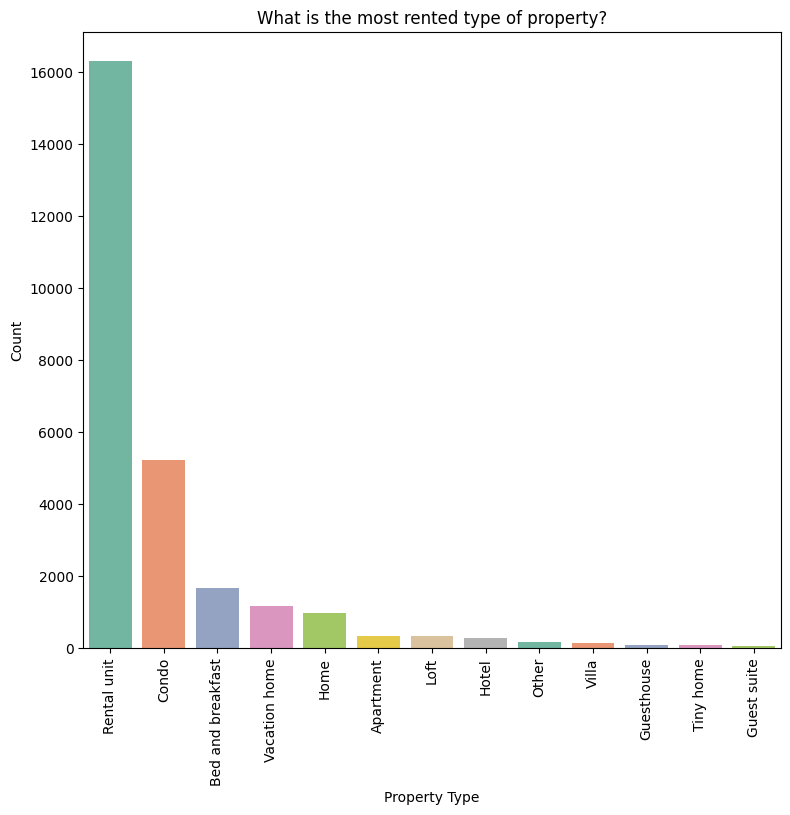

In [58]:
prop_order = df2['property_type'].value_counts().index

plt.figure(figsize=(9,8))
sns.countplot(data=df2, x='property_type', order=prop_order, palette='Set2')
plt.xlabel('Property Type')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.title('What is the most rented type of property?')
plt.show()

By far the properties are moslty listed as simply rental unit property type. That is a general term that does not imply either a home, apartment or any kind of property specifically.

Text(0.5, 1.0, 'What type of properties are most cost effective on average?')

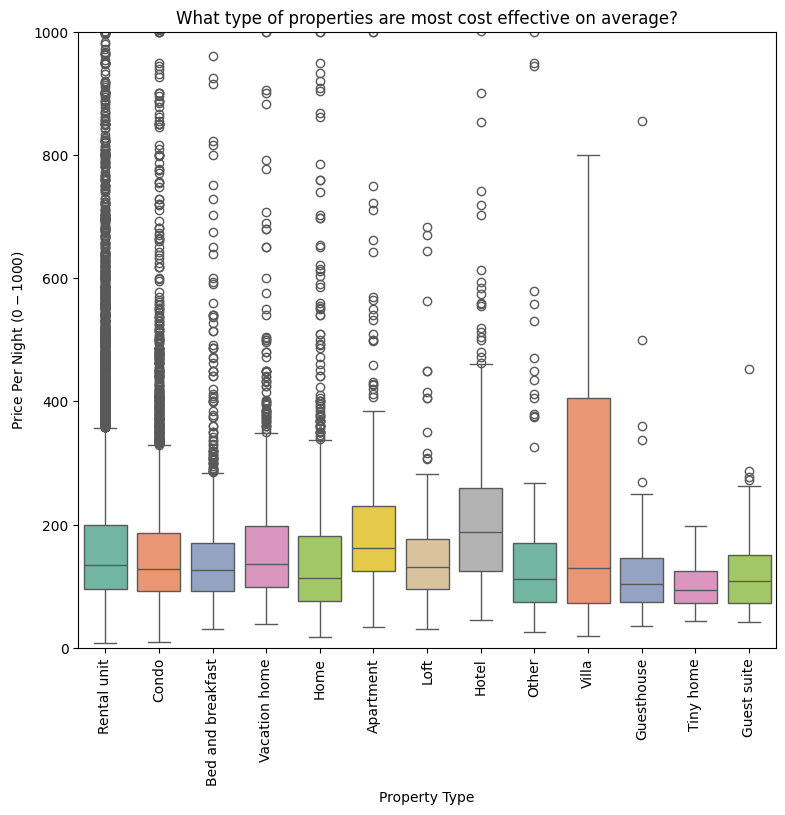

In [59]:
plt.figure(figsize=(9,8))
sns.boxplot(data=df2, x='property_type', y='price', order=prop_order, palette='Set2')
plt.xlabel('Property Type')
plt.xticks(rotation=90)
plt.ylabel('Price Per Night ($0-$1000)')
plt.ylim(0, 1000)
plt.title('What type of properties are most cost effective on average?')

Most of the properties cost around \$100 per night. There is variance in prices between them. Their means vary inside this \$100 - \$200 range.

We can observe that rooms which hotels retn via AirBnB tend to be the most expensive, while tiny home are the cheapest option usually.

There is the highest number of outliers inside the rental unit category, but that is to be expected since that is a very generic term

Text(0.5, 1.0, 'What type of room is priced the lowest on average?')

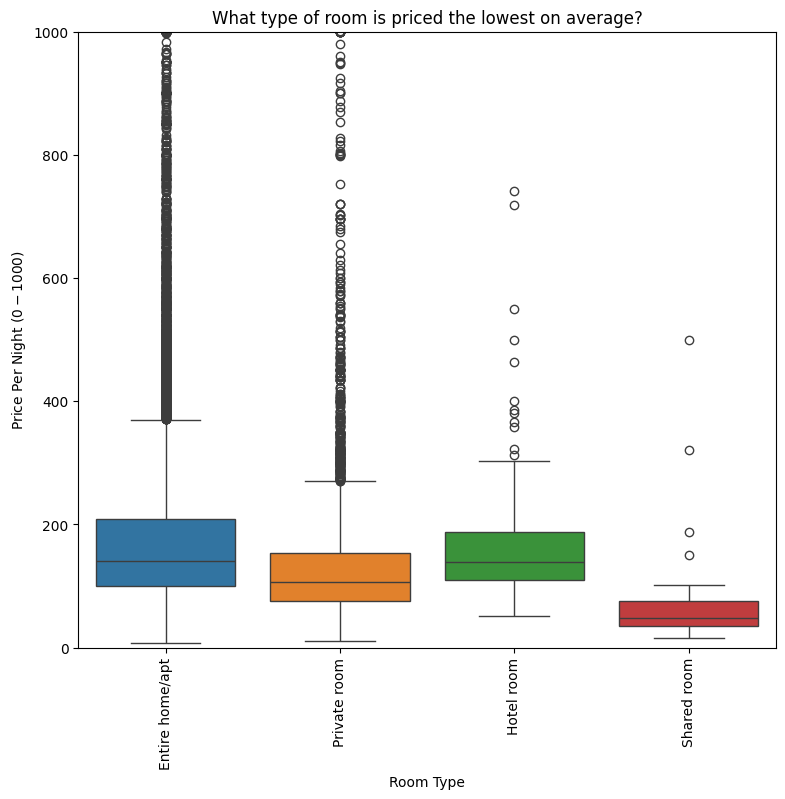

In [60]:
plt.figure(figsize=(9,8))
sns.boxplot(data=df2, x='room_type', y='price', palette='tab10')
plt.xlabel('Room Type')
plt.xticks(rotation=90)
plt.ylabel('Price Per Night ($0-$1000)')
plt.ylim(0, 1000)
plt.title('What type of room is priced the lowest on average?')

The shared rooms are very distinctly the cheapest option when renting the airbnb.

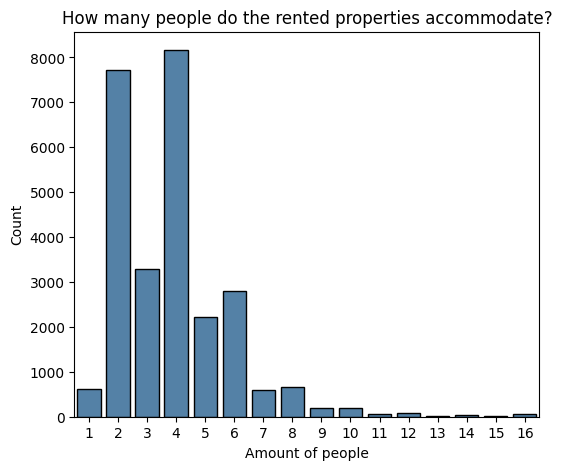

In [61]:
plt.figure(figsize=(6,5))
sns.countplot(data=df2, x='accommodates', color='steelblue', edgecolor='black')
plt.xlabel('Amount of people')
plt.ylabel('Count')
plt.title('How many people do the rented properties accommodate?')
plt.show()

Most of the properties accommodate 2-4 people. There are some more spacious properties that can take even 8+ people but there is a smaller portion of the listings.

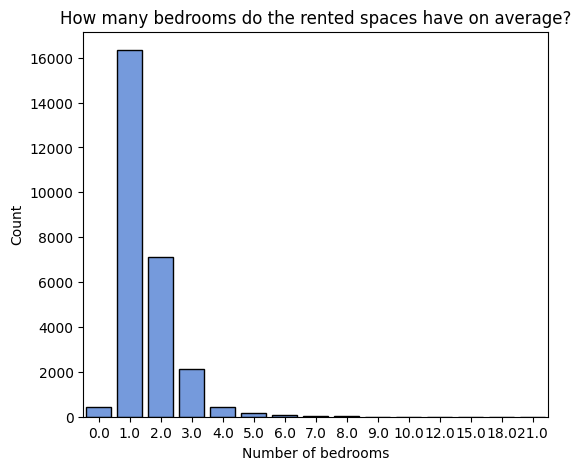

In [64]:
plt.figure(figsize=(6,5))
sns.countplot(data=df2, x='bedrooms', color='cornflowerblue', edgecolor='black')
plt.xlabel('Number of bedrooms')
plt.ylabel('Count')
plt.title('How many bedrooms do the rented spaces have on average?')
plt.show()

Almost all of the units have 1 to 2 bedroom max. Only small amount has more than that. Which also goes with the observation from the previous plot where we see that usually they accommodate 2-4 people.

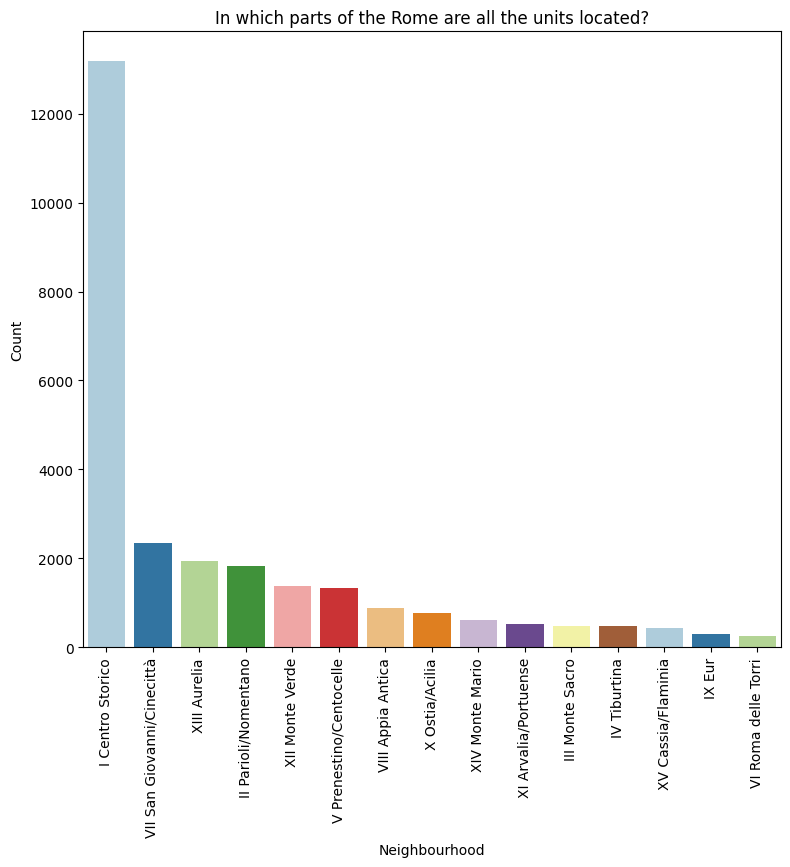

In [65]:
n_order = df2['neighbourhood_cleansed'].value_counts().index

plt.figure(figsize=(9,8))
sns.countplot(data=df2, x='neighbourhood_cleansed', order=n_order, palette='Paired')
plt.xlabel('Neighbourhood')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.title('In which parts of the Rome are all the units located?')
plt.show()

The most popular part of the city, by big margin, for renting out the properties is I Centro Storico. Almost 50% of all the listed properties are located in historic centre of Rome.

This could make it hard to see if there is any significant difference in prices between all these neighbourhoods, since half of the entries are in one category, while other half is made of 14 different neighbourhoods.

Text(0.5, 1.0, 'How the neighbourhood differ in their price ranges for the renting units?')

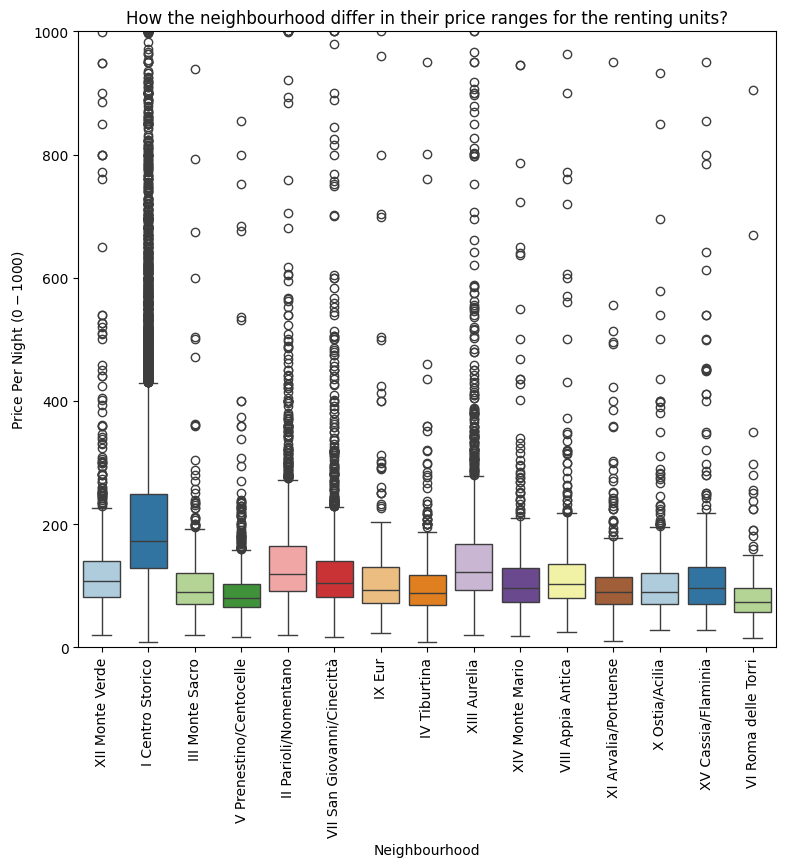

In [66]:
plt.figure(figsize=(9,8))
sns.boxplot(data=df2, x='neighbourhood_cleansed', y='price', palette='Paired')
plt.xlabel('Neighbourhood')
plt.xticks(rotation=90)
plt.ylabel('Price Per Night ($0-$1000)')
plt.ylim(0, 1000)
plt.title('How the neighbourhood differ in their price ranges for the renting units?')

The most expensive neighbourhood to stay in per night is I Centro Storico, the most populated one with the rental units as well. Then, there is also XII Aurelia and II Parioli/Nomentano which are also in general on a higher priced end. If however you are travelling on a budget it might be a good idea to look at neighbourhoods such as VI Roma delle Torri and V Prenestino/Centocelle.

Text(0.5, 1.0, 'Do the higher priced rental units get higher review scores?')

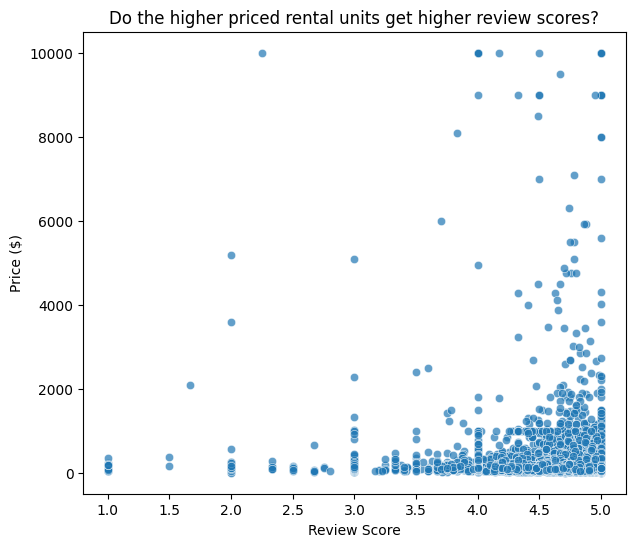

In [67]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=df2, x='review_scores_value', y='price', alpha=0.7)
plt.xlabel('Review Score')
plt.ylabel('Price ($)')
plt.title('Do the higher priced rental units get higher review scores?')

As we can see the higher priced places to not tend to get better scores and lower priced ones. All the score are bunched up between 4.0-5.0 indicating the score the proeprty will get in the review does not depend on the price, but on some other metrics.

### Handling Missing Values

In [68]:
train_missing = X_train.isna().sum() / len(X_train) * 100
val_missing = X_val.isna().sum() / len(X_val) * 100
test_missing = X_test.isna().sum() / len(X_test) * 100

missing_data_report2 = pd.DataFrame({'Train': train_missing, 'Validation': val_missing, 'Test': test_missing})
missing_data_report2 = missing_data_report2[missing_data_report2.sum(axis=1) > 0]
missing_data_report2

,Train,Validation,Test
minimum_maximum_nights,0.059804,0.029904,0.119581
bathrooms,0.026164,0.000000,0.029895
host_response_time,14.072662,14.802632,13.393124
host_since,0.029902,0.029904,0.000000
bedrooms,0.082231,0.119617,0.119581
last_review,12.809300,11.901914,13.333333
review_scores_communication,12.809300,11.901914,13.363229
review_scores_value,12.809300,11.901914,13.393124


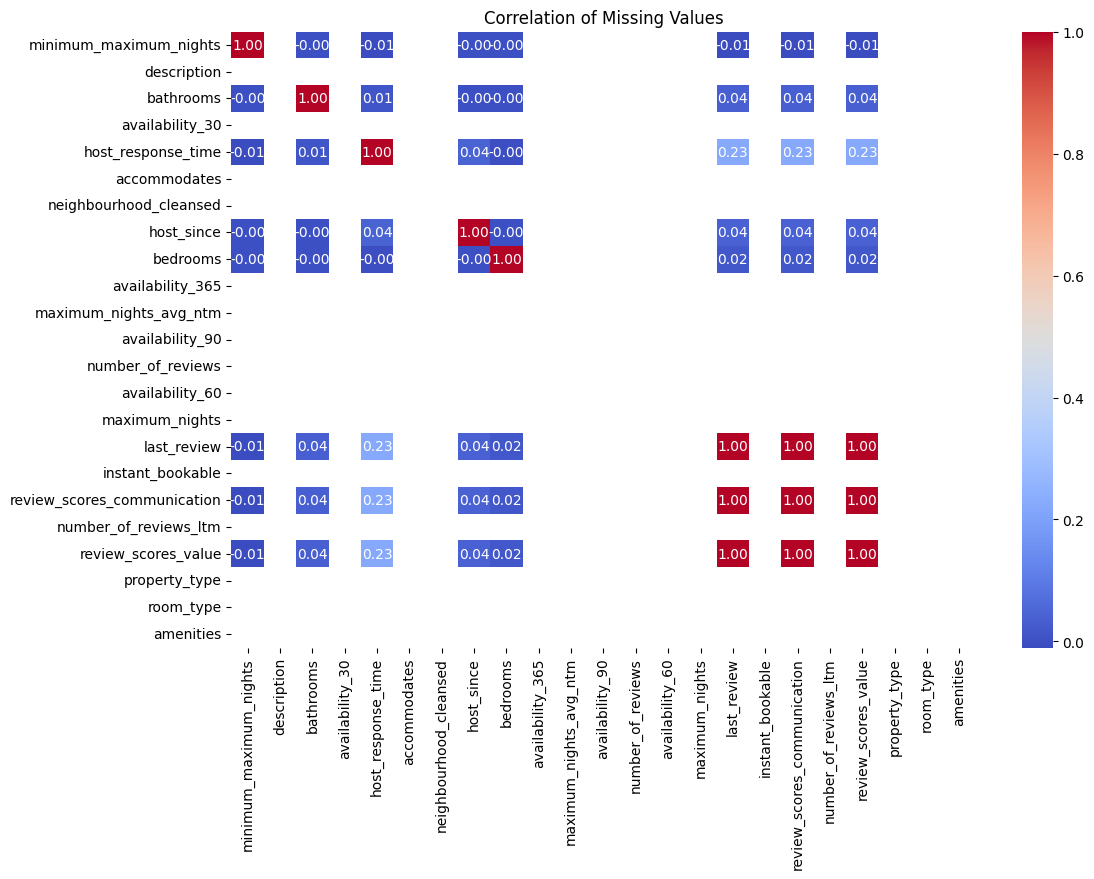

In [69]:
missing_corr = X_train.isna().astype(int).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(missing_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Missing Values')
plt.show()

Most of the correlations between misssing values are irrelevant. The missingness appears to be at random.

Howver there is this box of 1.00 correlations between last_review, review_scores_communication and review_scores_value. If one of them is missing, the other one is guaranteed to be missing as well.

In [70]:
X_train[X_train['last_review'].isna()][['number_of_reviews','review_scores_communication','review_scores_value']]

,number_of_reviews,review_scores_communication,review_scores_value
30777,0,NaN,NaN
35584,0,NaN,NaN
24096,0,NaN,NaN
6753,0,NaN,NaN
29041,0,NaN,NaN
...,...,...,...
11643,0,NaN,NaN
30306,0,NaN,NaN
25135,0,NaN,NaN
34845,0,NaN,NaN


When there is no reviews (number_of_reviews=0), there can be no last_review, review_scores_communication and review_scores_value.

Missingness in these columns in dependent on presence of the reviews. number_of_reviews apperas to captures the presence of the reviews and similar information about the reviews, so these 3 columns will be dropped.

In [71]:
X_train = X_train.drop(['last_review', 'review_scores_communication', 'review_scores_value'], axis=1)
X_val = X_val.drop(['last_review', 'review_scores_communication', 'review_scores_value'], axis=1)
X_test = X_test.drop(['last_review', 'review_scores_communication', 'review_scores_value'], axis=1)

In [72]:
train_missing = X_train.isna().sum() / len(X_train) * 100
val_missing = X_val.isna().sum() / len(X_val) * 100
test_missing = X_test.isna().sum() / len(X_test) * 100

missing_data_report3 = pd.DataFrame({'Train': train_missing, 'Validation': val_missing, 'Test': test_missing})
missing_data_report3 = missing_data_report3[missing_data_report3.sum(axis=1) > 0]
missing_data_report3

,Train,Validation,Test
minimum_maximum_nights,0.059804,0.029904,0.119581
bathrooms,0.026164,0.000000,0.029895
host_response_time,14.072662,14.802632,13.393124
host_since,0.029902,0.029904,0.000000
bedrooms,0.082231,0.119617,0.119581


For the host_response_time it makes sense to just fill in missing data with 'unknown'. It will be just another possible category for this feature.

In [73]:
X_train['host_response_time'].unique()

array(['within an hour', 'within a few hours', 'within a day', nan,
       'a few days or more'], dtype=object)

In [74]:
X_train['host_response_time'] = X_train['host_response_time'].fillna('unknown')
X_val['host_response_time'] = X_val['host_response_time'].fillna('unknown')
X_test['host_response_time'] = X_test['host_response_time'].fillna('unknown')

For all the other columns since the missing percentage is incredibly low, imputing t=with the median seems like the best option. It will not introduce any significant bias into the dataset.

In [75]:
X_train['host_for'] = 2025 - X_train['host_since']
X_val['host_for'] = 2025 - X_val['host_since']
X_test['host_for'] = 2025 - X_test['host_since']

In [76]:
median_host_for = X_train['host_for'].median()
X_train['host_for'] = X_train['host_for'].fillna(median_host_for)
X_val['host_for'] = X_val['host_for'].fillna(median_host_for)

In [77]:
X_train = X_train.drop('host_since', axis=1)
X_val = X_val.drop('host_since', axis=1)
X_test = X_test.drop('host_since', axis=1)

In [78]:
median_bedrooms = X_train['bedrooms'].median()
X_train['bedrooms'] = X_train['bedrooms'].fillna(median_bedrooms)
X_val['bedrooms'] = X_val['bedrooms'].fillna(median_bedrooms)
X_test['bedrooms'] = X_test['bedrooms'].fillna(median_bedrooms)

In [79]:
median_baths = X_train['bathrooms'].median()
X_train['bathrooms'] = X_train['bathrooms'].fillna(median_baths)
X_test['bathrooms'] = X_test['bathrooms'].fillna(median_baths)

In [80]:
median_nights = X_train['minimum_maximum_nights'].median()
X_train['minimum_maximum_nights'] = X_train['minimum_maximum_nights'].fillna(median_nights)
X_val['minimum_maximum_nights'] = X_val['minimum_maximum_nights'].fillna(median_nights)
X_test['minimum_maximum_nights'] = X_test['minimum_maximum_nights'].fillna(median_nights)

In [81]:
train_missing = X_train.isna().sum() / len(X_train) * 100
val_missing = X_val.isna().sum() / len(X_val) * 100
test_missing = X_test.isna().sum() / len(X_test) * 100

missing_data_report4 = pd.DataFrame({'Train': train_missing, 'Validation': val_missing, 'Test': test_missing})
missing_data_report4 = missing_data_report4[missing_data_report4.sum(axis=1) > 0]
missing_data_report4

,Train,Validation,Test


In [82]:
print('Shape of the sets after handling the missing values:')
print('----------------------------------------------------')
print('Shape of the training set: ', X_train.shape)
print('Shape of the validation set: ', X_val.shape)
print('Shape of the test set: ', X_test.shape)

Shape of the sets after handling the missing values:
----------------------------------------------------
Shape of the training set:  (26754, 20)
Shape of the validation set:  (3344, 20)
Shape of the test set:  (3345, 20)


In [83]:
numerical_cols = X_train.select_dtypes(include=['number']).columns
X_train[numerical_cols].agg(['min', 'max']).T

,min,max
minimum_maximum_nights,1.0,1825.0
bathrooms,0.5,15.5
availability_30,0.0,30.0
accommodates,1.0,16.0
bedrooms,0.0,21.0
availability_365,0.0,365.0
maximum_nights_avg_ntm,1.0,9579.8
availability_90,0.0,90.0
number_of_reviews,0.0,1244.0
availability_60,0.0,60.0


ALl these values seem to be perfectly realistic, except for maximum value maximum_nights_avg_ntm which is 9579.8. Since the maximum_nights is 1825 it does not make any sense fot this column to be so much higher. 9579.8 is 26 years compared to 1825 nights= 5 years.

In [84]:
upper_limit = 1825.0

X_train['maximum_nights_avg_ntm'] = X_train['maximum_nights_avg_ntm'].clip(upper=upper_limit)
X_val['maximum_nights_avg_ntm']   = X_val['maximum_nights_avg_ntm'].clip(upper=upper_limit)
X_test['maximum_nights_avg_ntm']  = X_test['maximum_nights_avg_ntm'].clip(upper=upper_limit)

In [85]:
X_train.to_parquet('X_train3.parquet')
X_val.to_parquet('X_val3.parquet')
X_test.to_parquet('X_test3.parquet')

### Encoding the Features

In [86]:
pip install sentence-transformers

Description column is written in natural, everyday language. Traditional methods which count the words and their frequencies could potentially miss some context and synonyms. Sentence Transformers map the entire text to a high dimensiaonl vector space where snetences with similar meanings are clustered close to each other.

In [87]:
from sentence_transformers import SentenceTransformer

train_text = X_train['description'].tolist()
val_text = X_val['description'].tolist()
test_text = X_test['description'].tolist()

encoder = SentenceTransformer('all-MiniLM-L6-v2')

train_embeds = encoder.encode(train_text, show_progress_bar=True)
val_embeds = encoder.encode(val_text, show_progress_bar=True)
test_embeds = encoder.encode(test_text, show_progress_bar=True)

embed_cols = [f"desc_dim_{i}" for i in range(train_embeds.shape[1])]

X_train_text = pd.DataFrame(train_embeds, columns=embed_cols, index=X_train.index)
X_val_text = pd.DataFrame(val_embeds, columns=embed_cols, index=X_val.index)
X_test_text = pd.DataFrame(test_embeds, columns=embed_cols, index=X_test.index)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/837 [00:00<?, ?it/s]

Batches:   0%|          | 0/105 [00:00<?, ?it/s]

Batches:   0%|          | 0/105 [00:00<?, ?it/s]

In [88]:
X_train_text.to_parquet('train_embeddings.parquet')
X_val_text.to_parquet('val_embeddings.parquet')
X_test_text.to_parquet('test_embeddings.parquet')

In [89]:
X_train = pd.concat([X_train.drop(columns=['description']), X_train_text], axis=1)
X_val = pd.concat([X_val.drop(columns=['description']), X_val_text], axis=1)
X_test = pd.concat([X_test.drop(columns=['description']), X_test_text], axis=1)

X_train

,minimum_maximum_nights,bathrooms,availability_30,host_response_time,accommodates,neighbourhood_cleansed,bedrooms,availability_365,maximum_nights_avg_ntm,availability_90,number_of_reviews,availability_60,maximum_nights,instant_bookable,number_of_reviews_ltm,property_type,room_type,amenities,host_for,desc_dim_0,desc_dim_1,desc_dim_2,desc_dim_3,desc_dim_4,desc_dim_5,desc_dim_6,desc_dim_7,desc_dim_8,desc_dim_9,desc_dim_10,desc_dim_11,desc_dim_12,desc_dim_13,desc_dim_14,desc_dim_15,desc_dim_16,desc_dim_17,desc_dim_18,desc_dim_19,desc_dim_20,desc_dim_21,desc_dim_22,desc_dim_23,desc_dim_24,desc_dim_25,desc_dim_26,desc_dim_27,desc_dim_28,desc_dim_29,desc_dim_30,desc_dim_31,desc_dim_32,desc_dim_33,desc_dim_34,desc_dim_35,desc_dim_36,desc_dim_37,desc_dim_38,desc_dim_39,desc_dim_40,desc_dim_41,desc_dim_42,desc_dim_43,desc_dim_44,desc_dim_45,desc_dim_46,desc_dim_47,desc_dim_48,desc_dim_49,desc_dim_50,desc_dim_51,desc_dim_52,desc_dim_53,desc_dim_54,desc_dim_55,desc_dim_56,desc_dim_57,desc_dim_58,desc_dim_59,desc_dim_60,desc_dim_61,desc_dim_62,desc_dim_63,desc_dim_64,desc_dim_65,desc_dim_66,desc_dim_67,desc_dim_68,desc_dim_69,desc_dim_70,desc_dim_71,desc_dim_72,desc_dim_73,desc_dim_74,desc_dim_75,desc_dim_76,desc_dim_77,desc_dim_78,desc_dim_79,desc_dim_80,desc_dim_81,desc_dim_82,desc_dim_83,desc_dim_84,desc_dim_85,desc_dim_86,desc_dim_87,desc_dim_88,desc_dim_89,desc_dim_90,desc_dim_91,desc_dim_92,desc_dim_93,desc_dim_94,desc_dim_95,desc_dim_96,desc_dim_97,desc_dim_98,desc_dim_99,desc_dim_100,desc_dim_101,desc_dim_102,desc_dim_103,desc_dim_104,desc_dim_105,desc_dim_106,desc_dim_107,desc_dim_108,desc_dim_109,desc_dim_110,desc_dim_111,desc_dim_112,desc_dim_113,desc_dim_114,desc_dim_115,desc_dim_116,desc_dim_117,desc_dim_118,desc_dim_119,desc_dim_120,desc_dim_121,desc_dim_122,desc_dim_123,desc_dim_124,desc_dim_125,desc_dim_126,desc_dim_127,desc_dim_128,desc_dim_129,desc_dim_130,desc_dim_131,desc_dim_132,desc_dim_133,desc_dim_134,desc_dim_135,desc_dim_136,desc_dim_137,desc_dim_138,desc_dim_139,desc_dim_140,desc_dim_141,desc_dim_142,desc_dim_143,desc_dim_144,desc_dim_145,desc_dim_146,desc_dim_147,desc_dim_148,desc_dim_149,desc_dim_150,desc_dim_151,desc_dim_152,desc_dim_153,desc_dim_154,desc_dim_155,desc_dim_156,desc_dim_157,desc_dim_158,desc_dim_159,desc_dim_160,desc_dim_161,desc_dim_162,desc_dim_163,desc_dim_164,desc_dim_165,desc_dim_166,desc_dim_167,desc_dim_168,desc_dim_169,desc_dim_170,desc_dim_171,desc_dim_172,desc_dim_173,desc_dim_174,desc_dim_175,desc_dim_176,desc_dim_177,desc_dim_178,desc_dim_179,desc_dim_180,desc_dim_181,desc_dim_182,desc_dim_183,desc_dim_184,desc_dim_185,desc_dim_186,desc_dim_187,desc_dim_188,desc_dim_189,desc_dim_190,desc_dim_191,desc_dim_192,desc_dim_193,desc_dim_194,desc_dim_195,desc_dim_196,desc_dim_197,desc_dim_198,desc_dim_199,desc_dim_200,desc_dim_201,desc_dim_202,desc_dim_203,desc_dim_204,desc_dim_205,desc_dim_206,desc_dim_207,desc_dim_208,desc_dim_209,desc_dim_210,desc_dim_211,desc_dim_212,desc_dim_213,desc_dim_214,desc_dim_215,desc_dim_216,desc_dim_217,desc_dim_218,desc_dim_219,desc_dim_220,desc_dim_221,desc_dim_222,desc_dim_223,desc_dim_224,desc_dim_225,desc_dim_226,desc_dim_227,desc_dim_228,desc_dim_229,desc_dim_230,desc_dim_231,desc_dim_232,desc_dim_233,desc_dim_234,desc_dim_235,desc_dim_236,desc_dim_237,desc_dim_238,desc_dim_239,desc_dim_240,desc_dim_241,desc_dim_242,desc_dim_243,desc_dim_244,desc_dim_245,desc_dim_246,desc_dim_247,desc_dim_248,desc_dim_249,desc_dim_250,desc_dim_251,desc_dim_252,desc_dim_253,desc_dim_254,desc_dim_255,desc_dim_256,desc_dim_257,desc_dim_258,desc_dim_259,desc_dim_260,desc_dim_261,desc_dim_262,desc_dim_263,desc_dim_264,desc_dim_265,desc_dim_266,desc_dim_267,desc_dim_268,desc_dim_269,desc_dim_270,desc_dim_271,desc_dim_272,desc_dim_273,desc_dim_274,desc_dim_275,desc_dim_276,desc_dim_277,desc_dim_278,desc_dim_279,desc_dim_280,desc_dim_281,desc_dim_282,desc_dim_283,desc_dim_284,desc_dim_285,desc_dim_286,desc_dim_287,desc_dim_288,desc_dim_289,desc_dim_290,desc_dim_291,desc_dim_292,

In [90]:
X_train.to_parquet('X_train_embedded.parquet')
X_val.to_parquet('X_val_embedded.parquet')
X_test.to_parquet('X_test_embedded.parquet')

Amenities column is a colection of the amenities each property has. Using the One Hot Encoder for each category for encoding this column would turn each row into separate category provided even if for example they had same amenities written in different order. Using MultiLabelBinarizer turns each of the possible amenities into a category and then if the property has it it will be labeled with 1 for that amenity.

In [91]:
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer

def clean_list(x):
    if isinstance(x, (list, np.ndarray)):
        return [str(item).lower().strip() for item in x if pd.notna(item)]

    return []

X_train['amenities'] = X_train['amenities'].apply(clean_list)
X_val['amenities'] = X_val['amenities'].apply(clean_list)
X_test['amenities'] = X_test['amenities'].apply(clean_list)


mlb = MultiLabelBinarizer()

train_encoded = mlb.fit_transform(X_train['amenities'])
val_encoded = mlb.transform(X_val['amenities'])
test_encoded = mlb.transform(X_test['amenities'])


amenity_cols = [f"has_{str(cls).replace(' ', '_')}" for cls in mlb.classes_]
X_train_am = pd.DataFrame(train_encoded, columns=amenity_cols, index=X_train.index)
X_val_am = pd.DataFrame(val_encoded, columns=amenity_cols, index=X_val.index)
X_test_am = pd.DataFrame(test_encoded, columns=amenity_cols, index=X_test.index)


min_listings = 0.01 * len(X_train)
frequent_amenities = X_train_am.columns[X_train_am.sum() >= min_listings].tolist()

X_train_am = X_train_am[frequent_amenities]
X_val_am = X_val_am.reindex(columns=frequent_amenities, fill_value=0)
X_test_am = X_test_am.reindex(columns=frequent_amenities, fill_value=0)

X_train_am

,has_32_inch_hdtv,has_ac_-_split_type_ductless_system,has_air_conditioning,has_baby_bath,has_babysitter_recommendations,has_backyard,has_baking_sheet,has_barbecue_utensils,has_bathtub,has_bbq_grill,has_bed_linens,has_bidet,has_blender,has_board_games,has_body_soap,has_books_and_reading_material,has_bread_maker,has_breakfast,has_building_staff,has_carbon_monoxide_alarm,has_ceiling_fan,has_central_air_conditioning,has_central_heating,has_children’s_books_and_toys,has_children’s_dinnerware,has_city_skyline_view,has_cleaning_available_during_stay,has_cleaning_products,has_clothing_storage,has_clothing_storage:_closet,has_clothing_storage:_closet_and_dresser,has_clothing_storage:_closet_and_wardrobe,"has_clothing_storage:_closet,_wardrobe,_and_dresser",has_clothing_storage:_walk-in_closet,has_clothing_storage:_wardrobe,has_clothing_storage:_wardrobe_and_dresser,has_coffee,has_coffee_maker,has_coffee_maker:_espresso_machine,"has_coffee_maker:_espresso_machine,_nespresso","has_coffee_maker:_espresso_machine,_pour-over_coffee",has_coffee_maker:_nespresso,has_coffee_maker:_pour-over_coffee,has_conditioner,has_cooking_basics,has_courtyard_view,has_crib,has_crib_-_always_at_the_listing,has_crib_-_available_upon_request,has_dedicated_workspace,has_dining_table,has_dishes_and_silverware,has_dishwasher,has_dryer,has_drying_rack_for_clothing,has_electric_stove,has_elevator,has_essentials,has_ethernet_connection,has_ev_charger,has_exercise_equipment,has_exterior_security_cameras_on_property,has_extra_pillows_and_blankets,has_fire_extinguisher,has_fire_pit,has_first_aid_kit,has_free_dryer_–_in_unit,has_free_parking_on_premises,has_free_street_parking,has_free_washer_–_in_unit,has_freezer,has_garden_view,has_gas_stove,has_hair_dryer,has_hangers,has_hdtv,has_heating,has_heating_-_split_type_ductless_system,has_high_chair,has_host_greets_you,has_hot_tub,has_hot_water,has_hot_water_kettle,has_housekeeping_-_available_at_extra_cost,has_indoor_fireplace,has_induction_stove,has_iron,has_keypad,has_kitchen,has_kitchenette,has_laundromat_nearby,has_lock_on_bedroom_door,has_lockbox,has_long_term_stays_allowed,has_luggage_dropoff_allowed,has_microwave,has_mini_fridge,has_mosquito_net,has_other_electric_stove,has_other_gas_stove,has_other_induction_stove,has_other_stainless_steel_gas_stove,has_other_stove,has_outdoor_dining_area,has_outdoor_furniture,has_outdoor_playground,has_outdoor_shower,has_outlet_covers,has_oven,has_pack_’n_play/travel_crib,has_pack_’n_play/travel_crib_-_always_at_the_listing,has_pack_’n_play/travel_crib_-_available_upon_request,has_paid_crib_-_available_upon_request,has_paid_pack_’n_play/travel_crib_-_available_upon_request,has_paid_parking_garage_off_premises,has_paid_parking_garage_on_premises,has_paid_parking_lot_on_premises,has_paid_parking_off_premises,has_paid_parking_on_premises,has_paid_street_parking_off_premises,has_park_view,has_patio_or_balcony,has_pets_allowed,has_piano,has_pocket_wifi,has_portable_fans,has_private_backyard_–_fully_fenced,has_private_entrance,has_private_living_room,has_private_patio_or_balcony,has_radiant_heating,has_refrigerator,has_rice_maker,has_room-darkening_shades,has_safe,has_self_check-in,has_shampoo,has_shared_backyard,has_shared_backyard_–_fully_fenced,has_shared_patio_or_balcony,has_shower_gel,has_single_level_home,has_single_oven,has_smart_lock,has_smoke_alarm,has_smoking_allowed,has_sound_system,has_stainless_steel_gas_stove,has_stainless_steel_oven,has_stainless_steel_single_oven,has_standalone_high_chair_-_available_upon_request,has_stove,has_sun_loungers,has_table_corner_guards,has_theme_room,has_toaster,has_trash_compactor,has_tv,has_tv_with_standard_cable,has_washer,has_wifi,has_window_ac_unit,has_window_guards,has_wine_glasses
32559,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [92]:
X_train_am.to_parquet('train_amenities.parquet')
X_val_am.to_parquet('val_amenities.parquet')
X_test_am.to_parquet('test_amenities.parquet')

In [93]:
X_train = pd.concat([X_train.drop(columns='amenities', errors='ignore'), X_train_am], axis=1)
X_val = pd.concat([X_val.drop(columns='amenities', errors='ignore'), X_val_am], axis=1)
X_test = pd.concat([X_test.drop(columns='amenities', errors='ignore'), X_test_am], axis=1)

In [94]:
X_train

,minimum_maximum_nights,bathrooms,availability_30,host_response_time,accommodates,neighbourhood_cleansed,bedrooms,availability_365,maximum_nights_avg_ntm,availability_90,number_of_reviews,availability_60,maximum_nights,instant_bookable,number_of_reviews_ltm,property_type,room_type,host_for,desc_dim_0,desc_dim_1,desc_dim_2,desc_dim_3,desc_dim_4,desc_dim_5,desc_dim_6,desc_dim_7,desc_dim_8,desc_dim_9,desc_dim_10,desc_dim_11,desc_dim_12,desc_dim_13,desc_dim_14,desc_dim_15,desc_dim_16,desc_dim_17,desc_dim_18,desc_dim_19,desc_dim_20,desc_dim_21,desc_dim_22,desc_dim_23,desc_dim_24,desc_dim_25,desc_dim_26,desc_dim_27,desc_dim_28,desc_dim_29,desc_dim_30,desc_dim_31,desc_dim_32,desc_dim_33,desc_dim_34,desc_dim_35,desc_dim_36,desc_dim_37,desc_dim_38,desc_dim_39,desc_dim_40,desc_dim_41,desc_dim_42,desc_dim_43,desc_dim_44,desc_dim_45,desc_dim_46,desc_dim_47,desc_dim_48,desc_dim_49,desc_dim_50,desc_dim_51,desc_dim_52,desc_dim_53,desc_dim_54,desc_dim_55,desc_dim_56,desc_dim_57,desc_dim_58,desc_dim_59,desc_dim_60,desc_dim_61,desc_dim_62,desc_dim_63,desc_dim_64,desc_dim_65,desc_dim_66,desc_dim_67,desc_dim_68,desc_dim_69,desc_dim_70,desc_dim_71,desc_dim_72,desc_dim_73,desc_dim_74,desc_dim_75,desc_dim_76,desc_dim_77,desc_dim_78,desc_dim_79,desc_dim_80,desc_dim_81,desc_dim_82,desc_dim_83,desc_dim_84,desc_dim_85,desc_dim_86,desc_dim_87,desc_dim_88,desc_dim_89,desc_dim_90,desc_dim_91,desc_dim_92,desc_dim_93,desc_dim_94,desc_dim_95,desc_dim_96,desc_dim_97,desc_dim_98,desc_dim_99,desc_dim_100,desc_dim_101,desc_dim_102,desc_dim_103,desc_dim_104,desc_dim_105,desc_dim_106,desc_dim_107,desc_dim_108,desc_dim_109,desc_dim_110,desc_dim_111,desc_dim_112,desc_dim_113,desc_dim_114,desc_dim_115,desc_dim_116,desc_dim_117,desc_dim_118,desc_dim_119,desc_dim_120,desc_dim_121,desc_dim_122,desc_dim_123,desc_dim_124,desc_dim_125,desc_dim_126,desc_dim_127,desc_dim_128,desc_dim_129,desc_dim_130,desc_dim_131,desc_dim_132,desc_dim_133,desc_dim_134,desc_dim_135,desc_dim_136,desc_dim_137,desc_dim_138,desc_dim_139,desc_dim_140,desc_dim_141,desc_dim_142,desc_dim_143,desc_dim_144,desc_dim_145,desc_dim_146,desc_dim_147,desc_dim_148,desc_dim_149,desc_dim_150,desc_dim_151,desc_dim_152,desc_dim_153,desc_dim_154,desc_dim_155,desc_dim_156,desc_dim_157,desc_dim_158,desc_dim_159,desc_dim_160,desc_dim_161,desc_dim_162,desc_dim_163,desc_dim_164,desc_dim_165,desc_dim_166,desc_dim_167,desc_dim_168,desc_dim_169,desc_dim_170,desc_dim_171,desc_dim_172,desc_dim_173,desc_dim_174,desc_dim_175,desc_dim_176,desc_dim_177,desc_dim_178,desc_dim_179,desc_dim_180,desc_dim_181,desc_dim_182,desc_dim_183,desc_dim_184,desc_dim_185,desc_dim_186,desc_dim_187,desc_dim_188,desc_dim_189,desc_dim_190,desc_dim_191,desc_dim_192,desc_dim_193,desc_dim_194,desc_dim_195,desc_dim_196,desc_dim_197,desc_dim_198,desc_dim_199,desc_dim_200,desc_dim_201,desc_dim_202,desc_dim_203,desc_dim_204,desc_dim_205,desc_dim_206,desc_dim_207,desc_dim_208,desc_dim_209,desc_dim_210,desc_dim_211,desc_dim_212,desc_dim_213,desc_dim_214,desc_dim_215,desc_dim_216,desc_dim_217,desc_dim_218,desc_dim_219,desc_dim_220,desc_dim_221,desc_dim_222,desc_dim_223,desc_dim_224,desc_dim_225,desc_dim_226,desc_dim_227,desc_dim_228,desc_dim_229,desc_dim_230,desc_dim_231,desc_dim_232,desc_dim_233,desc_dim_234,desc_dim_235,desc_dim_236,desc_dim_237,desc_dim_238,desc_dim_239,desc_dim_240,desc_dim_241,desc_dim_242,desc_dim_243,desc_dim_244,desc_dim_245,desc_dim_246,desc_dim_247,desc_dim_248,desc_dim_249,desc_dim_250,desc_dim_251,desc_dim_252,desc_dim_253,desc_dim_254,desc_dim_255,desc_dim_256,desc_dim_257,desc_dim_258,desc_dim_259,desc_dim_260,desc_dim_261,desc_dim_262,desc_dim_263,desc_dim_264,desc_dim_265,desc_dim_266,desc_dim_267,desc_dim_268,desc_dim_269,desc_dim_270,desc_dim_271,desc_dim_272,desc_dim_273,desc_dim_274,desc_dim_275,desc_dim_276,desc_dim_277,desc_dim_278,desc_dim_279,desc_dim_280,desc_dim_281,desc_dim_282,desc_dim_283,desc_dim_284,desc_dim_285,desc_dim_286,desc_dim_287,desc_dim_288,desc_dim_289,desc_dim_290,desc_dim_291,desc_dim_292,desc_dim_2

In [95]:
X_train['host_response_time'].unique()

array(['within an hour', 'within a few hours', 'within a day', 'unknown',
       'a few days or more'], dtype=object)

It makes sense to encode host_response_time column in a way that a fastest response is 0 (the lowest value) and the unknown is 4.

In [96]:
response_map = {
    'within an hour': 0,
    'within a few hours': 1,
    'within a day': 2,
    'a few days or more': 3,
    'unknown': 4
}
X_train['host_response_time'] = X_train['host_response_time'].map(response_map)
X_val['host_response_time'] = X_val['host_response_time'].map(response_map)
X_test['host_response_time'] = X_test['host_response_time'].map(response_map)

In [97]:
X_train['instant_bookable'] = X_train['instant_bookable'].replace('t', 1)
X_train['instant_bookable'] = X_train['instant_bookable'].replace('f', 0)

X_val['instant_bookable'] = X_val['instant_bookable'].replace('t', 1)
X_val['instant_bookable'] = X_val['instant_bookable'].replace('f', 0)

X_test['instant_bookable'] = X_test['instant_bookable'].replace('t', 1)
X_test['instant_bookable'] = X_test['instant_bookable'].replace('f', 0)

In [98]:
X_train.to_parquet('X_train4.parquet')
X_val.to_parquet('X_val4.parquet')
X_test.to_parquet('X_test4.parquet')

In [104]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

embedding_adapter = Ridge(alpha=1.0)
embedding_adapter.fit(train_embeds, y_train)

X_train['description_score'] = embedding_adapter.predict(train_embeds)
X_val['description_score'] = embedding_adapter.predict(val_embeds)
X_test['description_score'] = embedding_adapter.predict(test_embeds)

In [105]:
cols_to_drop = [col for col in X_train.columns if col.startswith('desc_dim_')]

X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_val = X_val.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

In [111]:
categorical_features = ['property_type', 'room_type', 'neighbourhood_cleansed']
numerical_features = X_train.select_dtypes(include='number').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

In [112]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

encoded_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = encoded_cat_features + list(numerical_features)

X_train_final = pd.DataFrame(X_train_transformed, columns=all_feature_names, index=X_train.index)
X_val_final = pd.DataFrame(X_val_transformed, columns=all_feature_names, index=X_val.index)
X_test_final = pd.DataFrame(X_test_transformed, columns=all_feature_names, index=X_test.index)

In [116]:
X_train_final.to_parquet('X_train_final.parquet')
X_val_final.to_parquet('X_val_final.parquet')
X_test_final.to_parquet('X_test_final.parquet')